In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'all_products.csv',
 'Amazon.csv',
 'amazon.sql',
 'archive',
 'archive.zip',
 'bookstore_inventory.csv',
 'camera_extracted_output.csv',
 'Cars.csv',
 'CLEANED_FINAL_PERFECT_OUTPUT.csv',
 'cleaned_jumia.xlsx',
 'cleaned_output.csv',
 'cleaned_smartphone_dataset.csv',
 'cleaned_smartphone_dataset.xlsx',
 'clean_output.csv',
 'FINAL_CLEANED_PHONES.csv',
 'FINAL_MERGED_OUTPUT.csv',
 'FINAL_PERFECT_OUTPUT.csv',
 'FINAL_SPLIT_OUTPUT.csv',
 'FINAL_UPDATED_MODELS.csv',
 'FINAL_UPDATED_MODELS_CLEANED.csv',
 'FINAL_UPDATED_MODELS_CLEANED_NO_UNKNOWN.csv',
 'FINAL_UPDATED_MODELS_V2.csv',
 'jumia.xlsx',
 'jumia_catalog_page_2_HTML_parser.html',
 'konga_full_data.csv',
 'konga_products.csv',
 'konga_products.xlsx',
 'konga_products_.xlsx',
 'konga_products_2.csv',
 'konga_products_2.xlsx',
 'konga_products_3.csv',
 'konga_products_3.xlsx',
 'online_sales_dataset.csv',
 'phones_cleaned_extracted.csv',
 'phones_extracted.csv',
 'phone_brand_extracted.csv',
 'PHONE_MODEL_EXTRA

In [3]:
product_info = pd.read_csv( 'cleaned_smartphone_dataset.csv')
product_info.head(10)

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size
0,"Samsung Galaxy A07 6.7"" 4GB RAM/128GB ROM - Black",162869.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a07-6....,7%,4.1,306,Samsung,4GB,128GB,Android,Black,Galaxy A07,6.70
1,XIAOMI REDMI A7 PRO - 6.9'' 4GB RAM/128GB ROM ...,166125.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-a7-pro-6...,8%,4.1,118,Xiaomi,4GB,128GB,Android,RED,REDMI A7,6.90
2,"Samsung Galaxy A17 6.7"" HD 6GB RAM/128GB ROM A...",235614.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a17-6....,9%,4.5,122,Samsung,6GB,128GB,Android 14,Black,Galaxy A17,6.70
3,"Poco C81 Pro 6.9"" 4GB RAM / 128GB ROM Android ...",136999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-c81-pro-6.9-4gb-...,24%,4.9,9,Poco,4GB,128GB,Android 15,Black,Poco C81 Pro,6.90
4,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,169946.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,750,Xiaomi,4GB,128GB,Android 15,Red,Redmi 15C,6.90
5,"Poco C85 6.9"" 6GB RAM / 128GB ROM Xiaomi Hyper...",168786.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-c85-6.9-6gb-ram-...,9%,4.4,137,Poco,6GB,128GB,HyperOS,Black,Poco C85,6.90
6,"MKTEL A19 Pro Mini 4.5"" Android 10 Phone 2+16G...",54554.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/mktel-a19-pro-mini-4....,35%,3.4,12,MKTEL,2GB,16GB,Android 10,NaN,A19,4.50
7,"Poco C85 6.9"" 8GB RAM / 256GB ROM Xiaomi Hyper...",208997.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/poco-c85-6.9-8gb-ram-...,9%,4.2,140,Poco,8GB,256GB,HyperOS,Black,Poco C85,6.90
8,"C Idea 6.7 Inches Smartphone,with android10 sn...",77280.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/c-idea-6.7-inches-sma...,46%,3.6,23,C Idea,8GB,64GB,Android10,NaN,NaN,6.70
9,redbeat D5 Android Smartphone 6.52inch IPS HD ...,99360.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/redbeat-d5-android-sm...,54%,3.5,127,Redbeat,28GB,6GB,NaN,red,NaN,6.52


In [4]:
product_info["price"].describe()

count    1.952000e+03
mean     5.681282e+05
std      6.277836e+05
min      4.180000e+04
25%      1.999990e+05
50%      3.400000e+05
75%      6.600000e+05
max      7.777777e+06
Name: price, dtype: float64

In [5]:
product_info.nlargest(20, "price")[["brand", "model", "price"]]

,brand,model,price
919,Samsung,NaN,7777777.0
1255,Huawei,Mate XT,4800000.0
1714,Huawei,Mate XT,4700000.0
1569,Samsung,Galaxy Z Fold 7,4464730.0
1040,Apple,iPhone 17 Pro Max,4398803.0
1619,Apple,iPhone 17 Pro Max,3822734.0
1167,Samsung,Galaxy Z Fold 8,3600000.0
1630,Samsung,NaN,3599000.0
1097,ZTE,NaN,3500000.0
1826,Samsung,Galaxy Z Fold 8,3450000.0


In [6]:
product_info.groupby("brand")["price"].mean().sort_values(ascending=False)

brand
Apple        1.208793e+06
Nubia        9.903330e+05
Google       9.778562e+05
OnePlus      9.496667e+05
Huawei       8.549262e+05
ZTE          8.112854e+05
Nothing      7.750000e+05
Motorola     7.210000e+05
Samsung      5.742017e+05
Lenovo       5.655000e+05
Poco         4.098019e+05
13           3.990000e+05
OPPO         3.940289e+05
HONOR        3.872219e+05
Xiaomi       3.698662e+05
K-Mobile     3.660000e+05
Vivo         3.513892e+05
Infinix      3.430889e+05
Spark        3.199990e+05
Tecno        3.131370e+05
Realme       2.801495e+05
Fire         2.424995e+05
Nokia        2.299990e+05
Infnix       1.980000e+05
itel         1.948946e+05
Camon        1.884540e+05
FOSSiBOT     1.854865e+05
Airtab       1.797586e+05
OUKITEL      1.748514e+05
Owwo         1.686165e+05
HMD          1.675710e+05
Nannee       1.659000e+05
Blackview    1.619860e+05
DOOGEE       1.610952e+05
Agm          1.586212e+05
Ccit         1.576320e+05
Landvo       1.552820e+05
Gaiaxy       1.490000e+05
Cubot 

In [7]:
product_info["brand"].value_counts().head(20)

brand
Samsung     748
Apple       264
Xiaomi      165
Tecno       113
itel         90
Infinix      87
Google       73
OPPO         56
Vivo         40
Poco         35
HONOR        33
OUKITEL      29
Airtab       29
Huawei       26
Landvo       17
Motorola     13
DOOGEE       10
Realme       10
OnePlus       9
FOSSiBOT      8
Name: count, dtype: int64

In [8]:
sorted(product_info["brand"].unique())

['128G',
 '13',
 'Agm',
 'Aiek',
 'Airtab',
 'Apple',
 'Blackview',
 'C Idea',
 'Camon',
 'Ccit',
 'Cubot',
 'DOOGEE',
 'Dnxt',
 'FOSSiBOT',
 'Fire',
 'FreeYond',
 'Gaiaxy',
 'Geetium',
 'Gen',
 'Google',
 'HMD',
 'HONOR',
 'Hot',
 'Hotwav',
 'Huawei',
 'Icom',
 'Infinix',
 'Infnix',
 'K-Mobile',
 'Landvo',
 'Lenovo',
 'Lesia',
 'MKTEL',
 'Motorola',
 'Mtn',
 'Mtng',
 'Nannee',
 'Nokia',
 'Nothing',
 'Nubia',
 'OPPO',
 'OUKITEL',
 'Oale',
 'OnePlus',
 'Owwo',
 'Philips',
 'Poco',
 'Realme',
 'Redbeat',
 'Rednni',
 'Ruioo',
 'Samsung',
 'Spark',
 'Tecno',
 'V.Polo',
 'Villaon',
 'Vivo',
 'Xiaomi',
 'ZTE',
 'itel']

In [9]:
product_info.loc[
    product_info["brand"] == "Galaxy",
    "name"
]

Series([], Name: name, dtype: str)

In [10]:
product_info.loc[
    product_info["brand"] == "Nothing",
    "name"
]

469     Nothing Headphone (1) Wireless On Ear Headphon...
1376    Nothing Phone (4a) Pro 5G 6.83'' 12GB RAM 256G...
Name: name, dtype: str

In [11]:
product_info[
    product_info.duplicated(subset=["name"], keep=False)
].sort_values("name")

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size
1491,"AirTab 10 Pro XL-6.8""HD+ Screen, Display, 24GB...",180000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/airtab-10-pro-xl-6.8h...,28%,0.0,0,Airtab,24GB,24GB,NaN,NaN,NaN,6.80
1000,"AirTab 10 Pro XL-6.8""HD+ Screen, Display, 24GB...",180000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/airtab-10-pro-xl-6.8h...,28%,0.0,0,Airtab,24GB,24GB,NaN,NaN,NaN,6.80
761,AirTab ORANGE i17 PRO MAX 6.9INCH 24GB RAM DUA...,180000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/airtab-orange-i17-pro...,0,0.0,0,Airtab,24GB,24GB,NaN,ORANGE,NaN,6.90
841,AirTab ORANGE i17 PRO MAX 6.9INCH 24GB RAM DUA...,175000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/airtab-orange-i17-pro...,40%,0.0,0,Airtab,24GB,24GB,NaN,ORANGE,NaN,6.90
843,AirTab S26 ULTRA 6.9INCH 24GB RAM 5G 1TB ROM A...,180000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/airtab-s26-ultra-6.9i...,36%,0.0,0,Airtab,24GB,24GB,NaN,Black,S26 ULTRA,6.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1421,"itel S26 Ultra 6.78"" 3D-Curved Amoled, Corning...",369999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/s26-ultra-6.78-3d-cur...,8%,0.0,0,itel,8GB,256GB,NaN,BLACK,S26 Ultra,6.78
1545,"itel S26 Ultra 6.78"" 3D-Curved Amoled, Corning...",369999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/itel-s26-ultra-6.78-3...,8%,0.0,0,itel,8GB,256GB,NaN,BLACK,S26 Ultra,6.78
1742,"itel SUPER 26 Ultra 6.78"" Curved AMOLED, 128GB...",267000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/itel-super-26-ultra-6...,6%,0.0,0,itel,8GB,128GB,NaN,NaN,SUPER 26 Ultra,6.78
693,"itel SUPER 26 Ultra 6.78"" Curved AMOLED, 128GB...",256950.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/itel-super-26-ultra-6...,14%,4.3,12,itel,8GB,128GB,NaN,NaN,SUPER 26 Ultra,6.78


In [12]:
product_info.duplicated(
    subset=["name", "price", "link"],
    keep=False
).sum()

np.int64(0)

In [13]:
product_info[
    product_info.duplicated(
        subset=["name", "price", "link"],
        keep=False
    )
].sort_values(["name", "price"])

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size


In [14]:
product_info[
    product_info["name"].str.contains(
        "Apple IPHONE 11 PRO MAX 256/4GB",
        case=False,
        na=False
    )
]

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size
1428,Apple IPHONE 11 PRO MAX 256/4GB (12PM+12PM+12P...,550000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/iphone-11-pro-max-256...,0,5.0,1,Apple,56GB,4GB,iOS,NaN,IPHONE 11 PRO MAX,6.5


In [15]:
repr(product_info.loc[1406, "link"])
repr(product_info.loc[1800, "link"])

"'https://www.jumia.com.ng/samsung-galaxy-s21-ultra-6.8-single-sim-5g-108mp-12812gb-5000mah-410986797.html'"

In [16]:
print(product_info.loc[1251, "link"])
print(product_info.loc[1902, "link"])

https://www.jumia.com.ng/redmi-note-15-pro-5g-6.83-8gb-256gb-dual-sim-7000mah-1.5k-amoled-display-sky-blue-xiaomi-mpg12055618.html
https://www.jumia.com.ng/motorola-razr-fold-5g-8.1-16gb-ram-512gb-rom-android-16-fifa-world-cup-26-collection-dual-sim-black-420066334.html


In [17]:
product_unique = (
    product_info
    .sort_values(
        by=["reviews", "rating", "price"],
        ascending=[False, False, True]
    )
    .drop_duplicates(subset=["name"], keep="first")
    .reset_index(drop=True)
)

print("Original shape:", product_info.shape)
print("Unique shape:", product_unique.shape)
print("Rows removed:", len(product_info) - len(product_unique))

Original shape: (1952, 14)
Unique shape: (1752, 14)
Rows removed: 200


In [18]:
product_unique["brand"] = product_unique["brand"].replace({
    "Galaxy": "Samsung",
    "Pixel": "Google",
    "13": None,
    "Genera": None,
    "Hair": None
})

In [19]:
product_unique.loc[
    product_unique["brand"] == "Spark",
    "brand"
] = "Tecno"

In [20]:
product_unique = product_unique.dropna(subset=["brand"]).reset_index(drop=True)

In [21]:
product_unique["model"] = (
    product_unique["model"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

In [22]:
apple_map = {
    "Iphone": "iPhone",
    "Iphone 11": "iPhone 11",
    "Iphone 11 Pro": "iPhone 11 Pro",
    "Iphone 11 Pro Max": "iPhone 11 Pro Max",
    "Iphone 12": "iPhone 12",
    "Iphone 12 Pro": "iPhone 12 Pro",
    "Iphone 12 Pro Max": "iPhone 12 Pro Max",
    "Iphone 13": "iPhone 13",
    "Iphone 13 Pro": "iPhone 13 Pro",
    "Iphone 13 Pro Max": "iPhone 13 Pro Max",
    "Iphone 14": "iPhone 14",
    "Iphone 14 Pro": "iPhone 14 Pro",
    "Iphone 14 Pro Max": "iPhone 14 Pro Max",
    "Iphone 15": "iPhone 15",
    "Iphone 15 Pro": "iPhone 15 Pro",
    "Iphone 15 Pro Max": "iPhone 15 Pro Max",
    "Iphone 16": "iPhone 16",
    "Iphone 16 Plus": "iPhone 16 Plus",
    "Iphone 16 Pro": "iPhone 16 Pro",
    "Iphone 16 Pro Max": "iPhone 16 Pro Max",
    "Iphone 17": "iPhone 17",
    "Iphone 17 Pro": "iPhone 17 Pro",
    "Iphone 17 Promax": "iPhone 17 Pro Max",
    "Iphone 17 Pro Max": "iPhone 17 Pro Max",
    "Iphone Air 256": "iPhone Air",
    "Iphone Se (3Rd Generation)": "iPhone SE (3rd generation)"
}

product_unique["model"] = product_unique["model"].replace(apple_map)

In [23]:
samsung_map = {
    "Galaxy Note10": "Galaxy Note 10",
    "Galaxy Note20": "Galaxy Note 20",
    "Galaxy Note8": "Galaxy Note 8",

    "Galaxy S10+": "Galaxy S10 Plus",
    "Galaxy S20+": "Galaxy S20 Plus",
    "Galaxy S8+": "Galaxy S8 Plus",
    "Galaxy S9+": "Galaxy S9 Plus",

    "Galaxy S9 Plus": "Galaxy S9 Plus",
    "Galaxy S9 Plus ": "Galaxy S9 Plus",

    "Galaxy S21Ultra": "Galaxy S21 Ultra",
    "Galaxy S22 Ultra": "Galaxy S22 Ultra",
    "Galaxy S23 Ultra": "Galaxy S23 Ultra",

    "S22 Ultra": "Galaxy S22 Ultra",
    "S23 Ultra": "Galaxy S23 Ultra",
    "S24 Ultra": "Galaxy S24 Ultra",
    "S25 Ultra": "Galaxy S25 Ultra",
    "S26 Ultra": "Galaxy S26 Ultra",

    "S10 Ultra": "Galaxy S10 Ultra",
    "S11 Ultra": "Galaxy S11 Ultra",

    "Galaxy Z Fold 6": "Galaxy Z Fold 6",
    "Galaxy Z Fold 7": "Galaxy Z Fold 7",
    "Galaxy Z Flip 6": "Galaxy Z Flip 6"
}

product_unique["model"] = product_unique["model"].replace(samsung_map)

In [24]:
tecno_map = {
    "Camon 20": "CAMON 20",
    "Camon 19": "CAMON 19",
    "Camon 40": "CAMON 40",
    "Camon40": "CAMON 40",
    "Camon 50": "CAMON 50",
    "Camon 20 Premier": "CAMON 20 PREMIER",

    "Spark 20": "SPARK 20",
    "Spark 30": "SPARK 30",
    "Spark 40": "SPARK 40",
    "Spark50": "SPARK 50",
    "Spark 50": "SPARK 50",

    "Pop20": "POP 20",
    "Pop 20": "POP 20",
    "Pop 9": "POP 9",

    "Smart20": "SMART 20",
    "Smart 20": "SMART 20",
    "Smart 10": "SMART 10"
}

product_unique["model"] = product_unique["model"].replace(tecno_map)

In [25]:
# Samsung A-series
product_unique.loc[
    product_unique["brand"].eq("Samsung") &
    product_unique["model"].str.match(r"^A\d+", na=False),
    "model"
] = "Galaxy " + product_unique.loc[
    product_unique["brand"].eq("Samsung") &
    product_unique["model"].str.match(r"^A\d+", na=False),
    "model"
]

In [26]:
# Itel A-series
product_unique.loc[
    product_unique["brand"].eq("Itel") &
    product_unique["model"].str.match(r"^A\d+", na=False),
    "model"
] = product_unique.loc[
    product_unique["brand"].eq("Itel") &
    product_unique["model"].str.match(r"^A\d+", na=False),
    "model"
]

In [27]:
# Samsung S-series
product_unique.loc[
    product_unique["brand"].eq("Samsung") &
    product_unique["model"].str.match(r"^S\d+", na=False),
    "model"
] = "Galaxy " + product_unique.loc[
    product_unique["brand"].eq("Samsung") &
    product_unique["model"].str.match(r"^S\d+", na=False),
    "model"
]

In [28]:
# Samsung Note-series
product_unique.loc[
    product_unique["brand"].eq("Samsung") &
    product_unique["model"].str.match(r"^Note\s*\d+", na=False),
    "model"
] = "Galaxy " + product_unique.loc[
    product_unique["brand"].eq("Samsung") &
    product_unique["model"].str.match(r"^Note\s*\d+", na=False),
    "model"
]

In [29]:
# Prefix Samsung A-series
mask = (
    (product_unique["brand"] == "Samsung") &
    (product_unique["model"].str.match(r"^A\d+[A-Z]*$", na=False))
)

product_unique.loc[mask, "model"] = (
    "Galaxy " + product_unique.loc[mask, "model"]
)

# Prefix itel A-series
mask = (
    (product_unique["brand"] == "Itel") &
    (product_unique["model"].str.match(r"^A\d+[A-Z]*$", na=False))
)

product_unique.loc[mask, "model"] = (
    "itel " + product_unique.loc[mask, "model"]
)

In [30]:
import re

def extract_blackview_model(row):
    if row["brand"] != "Blackview":
        return row["model"]

    name = row["name"]

    patterns = [
        r"Blackview\s+Smartphone\s+([A-Za-z0-9]+\s?[A-Za-z0-9]*)",  # Smartphone WAVE 10C
        r"Blackview\s+([A-Za-z]+\s?\d+)",                           # FORT 1
        r"Blackview\s+(BV\d+)",                                    # BV7300
    ]

    for pattern in patterns:
        m = re.search(pattern, name, re.I)
        if m:
            return m.group(1).strip()

    return row["model"]


product_unique["model"] = product_unique.apply(
    extract_blackview_model,
    axis=1
)

In [31]:
import re

def extract_agm_model(name):
    patterns = [
        r'AGM\s+(H\s*MAX)',                 # H MAX
        r'AGM\s+(H6\s+Leather\s+Lite)',     # H6 Leather Lite
        r'AGM\s+(H6\s+Leather)',            # H6 Leather
        r'AGM\s+(H6)',                      # H6
    ]

    for pattern in patterns:
        match = re.search(pattern, name, re.IGNORECASE)
        if match:
            return match.group(1).title()

    return None

mask = product_unique["brand"] == "Agm"

product_unique.loc[mask, "model"] = (
    product_unique.loc[mask, "name"]
    .apply(extract_agm_model)
)

#product_unique.loc[mask, ["brand", "name", "model"]]

In [32]:
import re

def extract_nubia_model(name):
    if pd.isna(name):
        return None

    # Remove the brand name
    name = re.sub(r'(?i)^Nubia\s+', '', name)
    name = re.sub(r'(?i)^ZTE\s+', '', name)

    # Nubia ZTE Focus Pro...
    m = re.search(r'Focus Pro', name, re.I)
    if m:
        return "Focus Pro"

    # RedMagic 10 Pro
    m = re.search(r'RedMagic\s*10\s*Pro', name, re.I)
    if m:
        return "RedMagic 10 Pro"

    # RedMagic 10s Pro
    m = re.search(r'RedMagic\s*10s\s*Pro', name, re.I)
    if m:
        return "RedMagic 10S Pro"

    return None


mask = product_unique["brand"] == "Nubia"

product_unique.loc[mask, "model"] = (
    product_unique.loc[mask, "name"]
    .apply(extract_nubia_model)
)

In [33]:
import re
import pandas as pd

def extract_huawei_model(name):
    if pd.isna(name):
        return None

    patterns = [
        r'Huawei\s+(Honor\s+\d+\w*)',
        r'Huawei\s+(Honor\s+Play\s+\d+\w*)',
        r'Huawei\s+(Pura\s+\d+\s+Ultra)',
        r'Huawei\s+(Pura\s+\d+)',
        r'Huawei\s+(Mate\s+X\d+)',
        r'Huawei\s+(Mate\s+\d+\s+Pro)',
        r'Huawei\s+(Mate\s+\d+)',
        r'Huawei\s+(Nova\s+\d+\w*)',
        r'Huawei\s+(nova\s+\d+\w*)',
        r'Huawei\s+(Psmart\+?\d*)',
        r'Huawei\s+(Enjoy\s+\d+\w*)',
        r'Huawei\s+(Y\d+\s*Prime\s*\d{4})',
        r'Huawei\s+(Y\d+Prime\d{4})',
        r'Huawei\s+(Y\d+\w*)',
        r'Huawei\s+(P\d+\s*Pro)',
        r'Huawei\s+(P\d+)',
        r'Huawei\s+(G\d+)',
    ]

    for pattern in patterns:
        m = re.search(pattern, name, re.I)
        if m:
            return m.group(1).title()

    return None


mask = product_unique["brand"] == "Huawei"

product_unique.loc[mask, "model"] = (
    product_unique.loc[mask]
    .apply(
        lambda row: extract_huawei_model(row["name"])
        if pd.isna(row["model"])
        else row["model"],
        axis=1
    )
)

In [34]:
import re

def extract_villaon_model(row):
    if row["brand"] != "Villaon":
        return row["model"]

    text = row["name"]

    patterns = [
        r'\b(V\d+\s*SE)\b',      # V20 SE
        r'\b(V\d+[A-Za-z]+)\b',  # V40s, V50s
        r'\b(V\d+)\b'            # V40, V20
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.I)
        if match:
            return match.group(1).upper()

    return row["model"]

product_unique["model"] = product_unique.apply(extract_villaon_model, axis=1)

In [35]:
product_unique.loc[
    (product_unique["brand"] == "C Idea") &
    (product_unique["model"].isna()),
    "model"
] = product_unique.loc[
    (product_unique["brand"] == "C Idea") &
    (product_unique["model"].isna()),
    "name"
]

In [36]:
mask = (
    (product_unique["brand"] == "FreeYond") &
    (product_unique["model"].isna())
)

product_unique.loc[mask, "model"] = (
    product_unique.loc[mask, "name"]
    .str.extract(
        r'FreeYond\s+FreeYond\s+([A-Za-z]+\d+(?:\s+(?:Pro|Plus|Max|Ultra))?)',
        expand=False
    )
)

In [37]:
import re

mask = (
    (product_unique["brand"] == "Oale") &
    (product_unique["model"].isna())
)

product_unique.loc[mask, "model"] = (
    product_unique.loc[mask, "name"]
    .str.extract(
        r'Oale\s+(.+?)\s+Android',
        flags=re.IGNORECASE,
        expand=False
    )
    .str.strip()
)

In [38]:
import re

def extract_ccit_model(name):
    if pd.isna(name):
        return None

    patterns = [
        r'\b(M17\s*Pro\s*Max)\b',
        r'\b(i17\s*Pro\s*Max)\b',
        r'\b(C30\s*Premier)\b',
        r'\b(S25\s*Ultra)\b',
    ]

    for pattern in patterns:
        match = re.search(pattern, name, re.I)
        if match:
            return match.group(1).title()

    return None


mask = product_unique["brand"] == "Ccit"

product_unique.loc[mask, "model"] = (
    product_unique.loc[mask, "name"]
    .apply(extract_ccit_model)
)

In [39]:
import re

# Extract Redbeat model
product_unique.loc[
    product_unique["brand"] == "Redbeat",
    "model"
] = (
    product_unique.loc[
        product_unique["brand"] == "Redbeat",
        "name"
    ]
    .str.extract(r"Redbeat\s+([A-Za-z0-9]+)", flags=re.I)[0]
)

In [40]:
import re
import numpy as np

# Function to extract RAM and Storage
def extract_ram_storage(text):
    if pd.isna(text):
        return np.nan, np.nan

    text = str(text)

    # Pattern: 8GB+256GB, 8GB/256GB, 8GB 256GB
    match = re.search(r'(\d+)\s*GB\s*[/+,\- ]\s*(\d+)\s*GB', text, re.I)
    if match:
        return int(match.group(1)), int(match.group(2))

    # Pattern: 12GB - 1TB
    match = re.search(r'(\d+)\s*GB.*?(\d+)\s*TB', text, re.I)
    if match:
        return int(match.group(1)), int(match.group(2)) * 1024

    # Pattern: 12GB - 512GB
    match = re.search(r'(\d+)\s*GB.*?(\d+)\s*GB', text, re.I)
    if match:
        return int(match.group(1)), int(match.group(2))

    return np.nan, np.nan


# Apply to the dataset
product_unique[["ram", "storage"]] = product_unique["name"].apply(
    lambda x: pd.Series(extract_ram_storage(x))
)

In [41]:
def extract_ram_storage(text):

    if pd.isna(text):
        return pd.Series([np.nan, np.nan])

    text = str(text)

    ram = np.nan
    storage = np.nan

    # --------------------------
    # Extract RAM
    # --------------------------

    m = re.search(r'(\d+)\s*GB\s*RAM', text, re.I)
    if m:
        ram = int(m.group(1))

    # --------------------------
    # Extract Storage
    # --------------------------

    m = re.search(r'(\d+)\s*TB', text, re.I)
    if m:
        storage = int(m.group(1)) * 1024
    else:
        m = re.search(r'(\d+)\s*GB\s*(?:ROM|Storage)', text, re.I)
        if m:
            storage = int(m.group(1))

    # --------------------------
    # If keywords were not found,
    # use the first two capacities
    # --------------------------

    if pd.isna(ram) or pd.isna(storage):

        values = re.findall(r'(\d+)\s*(GB|TB)', text, re.I)

        numbers = []

        for value, unit in values:

            value = int(value)

            if unit.upper() == "TB":
                value *= 1024

            numbers.append(value)

        # remove duplicates while keeping order
        numbers = list(dict.fromkeys(numbers))

        if len(numbers) >= 2:

            small = min(numbers[0], numbers[1])
            large = max(numbers[0], numbers[1])

            # RAM is almost always <=24GB
            if small <= 24:
                ram = small
                storage = large

    return pd.Series([ram, storage])


product_unique[["ram", "storage"]] = product_unique["name"].apply(extract_ram_storage)

In [42]:
import re
import pandas as pd
import numpy as np

def extract_ram_storage(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan])

    text = str(text).upper()

    # Convert TB to GB
    text = re.sub(
        r'(\d+)\s*TB',
        lambda m: str(int(m.group(1)) * 1024) + "GB",
        text
    )

    # Extract every GB value
    values = [int(x) for x in re.findall(r'(\d+)\s*GB', text)]

    # Remove unrealistic values
    values = [v for v in values if v <= 2048]

    if len(values) == 0:
        return pd.Series([np.nan, np.nan])

    values = sorted(values)

    ram = values[0]
    storage = values[-1]

    return pd.Series([ram, storage])


product_unique[["ram", "storage"]] = (
    product_unique["name"]
    .apply(extract_ram_storage)
)

In [43]:
import re
import pandas as pd
import numpy as np

def extract_ram_storage(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan])

    text = str(text).upper()

    # Convert TB to GB
    text = re.sub(
        r'(\d+)\s*TB',
        lambda m: f"{int(m.group(1))*1024}GB",
        text
    )

    # Extract all GB values
    numbers = [int(x) for x in re.findall(r'(\d+)\s*GB', text)]

    # Remove impossible values
    numbers = [n for n in numbers if n <= 2048]

    ram = np.nan
    storage = np.nan

    # RAM is usually between 2GB and 24GB
    ram_values = [n for n in numbers if 2 <= n <= 24]

    # Storage is usually 32GB or more
    storage_values = [n for n in numbers if n >= 32]

    if ram_values:
        ram = min(ram_values)

    if storage_values:
        storage = max(storage_values)

    return pd.Series([ram, storage])


product_unique[["ram", "storage"]] = (
    product_unique["name"]
    .apply(extract_ram_storage)
)

In [44]:
import re

# Extract RAM for Redbeat products like "4+64GB ROM"
product_unique.loc[
    product_unique["brand"] == "Redbeat",
    "ram"
] = (
    product_unique.loc[
        product_unique["brand"] == "Redbeat",
        "name"
    ]
    .str.extract(r'(\d+)\s*\+\s*\d+\s*GB', flags=re.I)[0]
    .astype(float)
)

In [45]:
import re
import numpy as np

def extract_missing_ram(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM
        r'(\d+(?:\.\d+)?)\s*GB\s*RAM',

        # 8G RAM
        r'(\d+(?:\.\d+)?)\s*G\s*RAM',

        # 6BG RAM
        r'(\d+(?:\.\d+)?)\s*BG\s*RAM',

        # 8+256GB
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB',

        # 8/256GB
        r'(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB',

        # 8GB/256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB',

        # 8GB ROM / 256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*ROM',

        # 8GB + 256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*\+\s*\d+\s*GB'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            ram = float(match.group(1))

            # Keep only realistic RAM values
            if 1 <= ram <= 24:
                return ram

    return np.nan

In [46]:
import re
import numpy as np
import pandas as pd

def extract_ram(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM, 8G RAM, 8GBRAM
        r'(\d+(?:\.\d+)?)\s*GB\s*RAM',
        r'(\d+(?:\.\d+)?)\s*G\s*RAM',

        # 6BG + 128GB
        r'(\d+(?:\.\d+)?)\s*BG\s*\+\s*\d+\s*GB',

        # 8+128GB, 8+128G
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB',
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*G\b',

        # 8/256GB or 8\256GB
        r'(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB',

        # 8GB/256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB',

        # (512+8) or (128+8)
        r'\(\s*\d+\s*\+\s*(\d+(?:\.\d+)?)\s*\)',

        # 128+8 without parentheses
        r'\b\d+\s*\+\s*(\d+(?:\.\d+)?)\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            ram = float(match.group(1))

            # Only accept realistic smartphone RAM
            if 1 <= ram <= 24:
                return ram

    return np.nan

In [47]:
import re
import numpy as np
import pandas as pd

def extract_ram_from_name(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM / 8G RAM / 8 GB RAM
        r'\b(\d+(?:\.\d+)?)\s*GB\s*RAM\b',
        r'\b(\d+(?:\.\d+)?)\s*G\s*RAM\b',

        # 6BG + 128GB
        r'\b(\d+(?:\.\d+)?)\s*BG\s*\+\s*\d+\s*GB\b',

        # 8+128GB / 8+128G
        r'\b(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB\b',
        r'\b(\d+(?:\.\d+)?)\s*\+\s*\d+\s*G\b',

        # 512+8 or 128+8
        r'\(\s*\d+\s*\+\s*(\d+(?:\.\d+)?)\s*\)',
        r'\b\d+\s*\+\s*(\d+(?:\.\d+)?)\b',

        # 8/256GB or 8\256GB
        r'\b(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB\b',

        # 8GB/256GB
        r'\b(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            value = float(match.group(1))

            # Smartphone RAM should normally be within this range
            if 1 <= value <= 24:
                return value

    return np.nan

In [48]:
import re
import numpy as np
import pandas as pd

def extract_storage(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 128GB ROM / 128G ROM
        r'\b(\d+(?:\.\d+)?)\s*GB\s*ROM\b',
        r'\b(\d+(?:\.\d+)?)\s*G\s*ROM\b',

        # 128GB / 128G
        r'\b(\d+(?:\.\d+)?)\s*GB\b',
        r'\b(\d+(?:\.\d+)?)\s*G\b',

        # 8+128GB or 8+128G
        r'\b\d+(?:\.\d+)?\s*\+\s*(\d+(?:\.\d+)?)\s*GB\b',
        r'\b\d+(?:\.\d+)?\s*\+\s*(\d+(?:\.\d+)?)\s*G\b',

        # 128/4GB or 256/4GB
        r'\b(\d+(?:\.\d+)?)\s*/\s*\d+(?:\.\d+)?\s*GB\b',

        # 128/4+4GB
        r'\b(\d+(?:\.\d+)?)\s*/\s*\d+(?:\.\d+)?\s*\+\s*\d+(?:\.\d+)?\s*GB\b',

        # 512+8 inside brackets
        r'\(\s*(\d+(?:\.\d+)?)\s*\+\s*\d+(?:\.\d+)?\s*\)',

        # 12PM+64PM → storage is usually the second number
        r'\b\d+\s*PM\s*\+\s*(\d+)\s*PM\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            storage = float(match.group(1))

            # Reasonable smartphone storage range
            if 8 <= storage <= 4096:
                return storage

    return np.nan

In [49]:
import re
import numpy as np
import pandas as pd

def extract_ram_from_name(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM / 8G RAM / 8 GB RAM
        r'\b(\d+(?:\.\d+)?)\s*GB\s*RAM\b',
        r'\b(\d+(?:\.\d+)?)\s*G\s*RAM\b',

        # 6BG + 128GB
        r'\b(\d+(?:\.\d+)?)\s*BG\s*\+\s*\d+\s*GB\b',

        # 8+128GB / 8+128G
        r'\b(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB\b',
        r'\b(\d+(?:\.\d+)?)\s*\+\s*\d+\s*G\b',

        # 512+8 or 128+8
        r'\(\s*\d+\s*\+\s*(\d+(?:\.\d+)?)\s*\)',
        r'\b\d+\s*\+\s*(\d+(?:\.\d+)?)\b',

        # 8/256GB or 8\256GB
        r'\b(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB\b',

        # 8GB/256GB
        r'\b(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            value = float(match.group(1))

            # Smartphone RAM should normally be within this range
            if 1 <= value <= 24:
                return value

    return np.nan

In [50]:
product_unique.isna().sum()

name             0
price            0
image            0
link             0
discount         0
rating           0
reviews          0
brand            0
ram            185
storage        126
os             160
color          436
model          219
screen_size    273
dtype: int64

In [51]:
import re
import numpy as np

def extract_missing_ram(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM
        r'(\d+(?:\.\d+)?)\s*GB\s*RAM',

        # 8G RAM
        r'(\d+(?:\.\d+)?)\s*G\s*RAM',

        # 6BG RAM
        r'(\d+(?:\.\d+)?)\s*BG\s*RAM',

        # 8+256GB
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB',

        # 8/256GB
        r'(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB',

        # 8GB/256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB',

        # 8GB ROM / 256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*ROM',

        # 8GB + 256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*\+\s*\d+\s*GB'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            ram = float(match.group(1))

            # Keep only realistic RAM values
            if 1 <= ram <= 24:
                return ram

    return np.nan

In [52]:
import re
import numpy as np
import pandas as pd

def extract_ram(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM, 8G RAM, 8GBRAM
        r'(\d+(?:\.\d+)?)\s*GB\s*RAM',
        r'(\d+(?:\.\d+)?)\s*G\s*RAM',

        # 6BG + 128GB
        r'(\d+(?:\.\d+)?)\s*BG\s*\+\s*\d+\s*GB',

        # 8+128GB, 8+128G
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB',
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*G\b',

        # 8/256GB or 8\256GB
        r'(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB',

        # 8GB/256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB',

        # (512+8) or (128+8)
        r'\(\s*\d+\s*\+\s*(\d+(?:\.\d+)?)\s*\)',

        # 128+8 without parentheses
        r'\b\d+\s*\+\s*(\d+(?:\.\d+)?)\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            ram = float(match.group(1))

            # Only accept realistic smartphone RAM
            if 1 <= ram <= 24:
                return ram

    return np.nan

In [53]:
import re
import numpy as np

def extract_missing_ram(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM
        r'(\d+(?:\.\d+)?)\s*GB\s*RAM',

        # 8G RAM
        r'(\d+(?:\.\d+)?)\s*G\s*RAM',

        # 6BG RAM
        r'(\d+(?:\.\d+)?)\s*BG\s*RAM',

        # 8+256GB
        r'(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB',

        # 8/256GB
        r'(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB',

        # 8GB/256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB',

        # 8GB ROM / 256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*ROM',

        # 8GB + 256GB
        r'(\d+(?:\.\d+)?)\s*GB\s*\+\s*\d+\s*GB'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            ram = float(match.group(1))

            # Keep only realistic RAM values
            if 1 <= ram <= 24:
                return ram

    return np.nan

In [54]:
import re
import numpy as np
import pandas as pd

def extract_ram_from_name(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 8GB RAM / 8G RAM / 8 GB RAM
        r'\b(\d+(?:\.\d+)?)\s*GB\s*RAM\b',
        r'\b(\d+(?:\.\d+)?)\s*G\s*RAM\b',

        # 6BG + 128GB
        r'\b(\d+(?:\.\d+)?)\s*BG\s*\+\s*\d+\s*GB\b',

        # 8+128GB / 8+128G
        r'\b(\d+(?:\.\d+)?)\s*\+\s*\d+\s*GB\b',
        r'\b(\d+(?:\.\d+)?)\s*\+\s*\d+\s*G\b',

        # 512+8 or 128+8
        r'\(\s*\d+\s*\+\s*(\d+(?:\.\d+)?)\s*\)',
        r'\b\d+\s*\+\s*(\d+(?:\.\d+)?)\b',

        # 8/256GB or 8\256GB
        r'\b(\d+(?:\.\d+)?)\s*[/\\]\s*\d+\s*GB\b',

        # 8GB/256GB
        r'\b(\d+(?:\.\d+)?)\s*GB\s*[/\\]\s*\d+\s*GB\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            value = float(match.group(1))

            # Smartphone RAM should normally be within this range
            if 1 <= value <= 24:
                return value

    return np.nan

In [55]:
import re
import numpy as np
import pandas as pd

def extract_storage(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 128GB ROM / 128G ROM
        r'\b(\d+(?:\.\d+)?)\s*GB\s*ROM\b',
        r'\b(\d+(?:\.\d+)?)\s*G\s*ROM\b',

        # 128GB / 128G
        r'\b(\d+(?:\.\d+)?)\s*GB\b',
        r'\b(\d+(?:\.\d+)?)\s*G\b',

        # 8+128GB or 8+128G
        r'\b\d+(?:\.\d+)?\s*\+\s*(\d+(?:\.\d+)?)\s*GB\b',
        r'\b\d+(?:\.\d+)?\s*\+\s*(\d+(?:\.\d+)?)\s*G\b',

        # 128/4GB or 256/4GB
        r'\b(\d+(?:\.\d+)?)\s*/\s*\d+(?:\.\d+)?\s*GB\b',

        # 128/4+4GB
        r'\b(\d+(?:\.\d+)?)\s*/\s*\d+(?:\.\d+)?\s*\+\s*\d+(?:\.\d+)?\s*GB\b',

        # 512+8 inside brackets
        r'\(\s*(\d+(?:\.\d+)?)\s*\+\s*\d+(?:\.\d+)?\s*\)',

        # 12PM+64PM → storage is usually the second number
        r'\b\d+\s*PM\s*\+\s*(\d+)\s*PM\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            storage = float(match.group(1))

            # Reasonable smartphone storage range
            if 8 <= storage <= 4096:
                return storage

    return np.nan

In [56]:
import re
import numpy as np
import pandas as pd

def extract_storage(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    patterns = [
        # 128GB ROM / 128G ROM
        r'\b(\d+(?:\.\d+)?)\s*GB\s*ROM\b',
        r'\b(\d+(?:\.\d+)?)\s*G\s*ROM\b',

        # 128GB / 128G
        r'\b(\d+(?:\.\d+)?)\s*GB\b',
        r'\b(\d+(?:\.\d+)?)\s*G\b',

        # 8+128GB or 8+128G
        r'\b\d+(?:\.\d+)?\s*\+\s*(\d+(?:\.\d+)?)\s*GB\b',
        r'\b\d+(?:\.\d+)?\s*\+\s*(\d+(?:\.\d+)?)\s*G\b',

        # 128/4GB or 256/4GB
        r'\b(\d+(?:\.\d+)?)\s*/\s*\d+(?:\.\d+)?\s*GB\b',

        # 128/4+4GB
        r'\b(\d+(?:\.\d+)?)\s*/\s*\d+(?:\.\d+)?\s*\+\s*\d+(?:\.\d+)?\s*GB\b',

        # 512+8 inside brackets
        r'\(\s*(\d+(?:\.\d+)?)\s*\+\s*\d+(?:\.\d+)?\s*\)',

        # 12PM+64PM → storage is usually the second number
        r'\b\d+\s*PM\s*\+\s*(\d+)\s*PM\b'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            storage = float(match.group(1))

            # Reasonable smartphone storage range
            if 8 <= storage <= 4096:
                return storage

    return np.nan

In [57]:
product_unique["product_model"] = (
    product_unique["brand"] + " " + product_unique["model"].fillna("")
).str.strip()

In [58]:
product_unique.groupby("product_model")["price"].mean()

product_model
128G                    99029.000000
Agm H Max              119640.000000
Agm H6                 191309.000000
Agm H6 Leather         169761.000000
Agm H6 Leather Lite    142635.000000
                           ...      
itel P65C              139999.000000
itel Power 80          207957.666667
itel Power80           200780.000000
itel Super 26 Ultra    307680.000000
itel Super 26Ultra     258569.000000
Name: price, Length: 365, dtype: float64

In [59]:
product_unique["product_model"].value_counts().head(50)

product_model
Google                          67
Xiaomi Redmi 15C                37
Samsung Galaxy Note 10          33
Apple iPhone 17 Pro Max         29
Samsung Galaxy S22 Ultra        28
Samsung Galaxy A07              26
Xiaomi                          23
Samsung Galaxy S10              23
Samsung Galaxy S21              22
Samsung Galaxy A17              21
Samsung Galaxy S23 Ultra        21
Samsung Galaxy A06              20
Samsung Galaxy S26 Ultra        20
Tecno SPARK 50                  19
Infinix SMART 20                18
Samsung Galaxy S22              18
Tecno SPARK 40                  18
Samsung Galaxy S21 Ultra        17
Apple                           17
Infinix Hot 70                  17
Apple iPhone 17                 17
Xiaomi Redmi A7                 16
Samsung Galaxy S21 Plus         16
Samsung Galaxy S24 Ultra        16
Apple iPhone 14 Pro Max         16
Samsung Galaxy S20 Ultra        15
Samsung Galaxy S22 Plus         15
Samsung Galaxy S23              15
Apple 

In [60]:
brand_counts = product_unique["brand"].value_counts()

product_unique["brand_grouped"] = product_unique["brand"].where(
    product_unique["brand"].isin(brand_counts[brand_counts >= 5].index),
    "Other"
)

In [61]:
# Original listing dataset
product_info

# One row per phone
product_unique

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size,product_model,brand_grouped
0,XIAOMI Redmi 15C 6.9'' 8GBRAM/256GB ROM Androi...,225999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,10%,4.1,992,Xiaomi,8.0,256.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
1,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,169946.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,750,Xiaomi,4.0,128.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
2,"Samsung Galaxy A06 6.7"" 4GB RAM/ 128GB ROM And...",149975.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a06-6....,17%,4.2,682,Samsung,4.0,128.0,Android 14,Black,Galaxy A06,6.7,Samsung Galaxy A06,Samsung
3,"Samsung Galaxy A06 6.7"" 4GB RAM/64GB ROM Andro...",123999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a06-6....,15%,4.1,615,Samsung,4.0,64.0,Android 14,Black,Galaxy A06,6.7,Samsung Galaxy A06,Samsung
4,XIAOMI Redmi 15C 6.9'' 4GB RAM/128GB ROM Andro...,168802.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,611,Xiaomi,4.0,128.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,Apple iPhone 17 Pro Max (1TB) – Silver (AFA),3822734.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/apple-iphone-17-pro-m...,0,0.0,0,Apple,NaN,1024.0,iOS,Silver,iPhone 17 Pro Max,6.3,Apple iPhone 17 Pro Max,Apple
1747,Apple iPhone 17 Pro Max (2TB) – Silver (AFA),4398803.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/apple-iphone-17-pro-m...,0,0.0,0,Apple,NaN,2048.0,iOS,Silver,iPhone 17 Pro Max,6.3,Apple iPhone 17 Pro Max,Apple
1748,"Samsung Galaxy Z Fold 7 5G 8.0"" -16GB RAM+ 1TB...",4464730.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-z-fold...,0,0.0,0,Samsung,16.0,1024.0,Android 16,BLACK,Galaxy Z Fold 7,8.0,Samsung Galaxy Z Fold 7,Samsung
1749,Huawei Mate XT Ultimate Design 10.2'' Tri-Fold...,4700000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/huawei-mate-xt-ultima...,2%,0.0,0,Huawei,16.0,1024.0,HarmonyOS,Black,Mate Xt,10.2,Huawei Mate Xt,Huawei


In [62]:
product_unique

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size,product_model,brand_grouped
0,XIAOMI Redmi 15C 6.9'' 8GBRAM/256GB ROM Androi...,225999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,10%,4.1,992,Xiaomi,8.0,256.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
1,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,169946.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,750,Xiaomi,4.0,128.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
2,"Samsung Galaxy A06 6.7"" 4GB RAM/ 128GB ROM And...",149975.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a06-6....,17%,4.2,682,Samsung,4.0,128.0,Android 14,Black,Galaxy A06,6.7,Samsung Galaxy A06,Samsung
3,"Samsung Galaxy A06 6.7"" 4GB RAM/64GB ROM Andro...",123999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a06-6....,15%,4.1,615,Samsung,4.0,64.0,Android 14,Black,Galaxy A06,6.7,Samsung Galaxy A06,Samsung
4,XIAOMI Redmi 15C 6.9'' 4GB RAM/128GB ROM Andro...,168802.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,611,Xiaomi,4.0,128.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,Apple iPhone 17 Pro Max (1TB) – Silver (AFA),3822734.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/apple-iphone-17-pro-m...,0,0.0,0,Apple,NaN,1024.0,iOS,Silver,iPhone 17 Pro Max,6.3,Apple iPhone 17 Pro Max,Apple
1747,Apple iPhone 17 Pro Max (2TB) – Silver (AFA),4398803.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/apple-iphone-17-pro-m...,0,0.0,0,Apple,NaN,2048.0,iOS,Silver,iPhone 17 Pro Max,6.3,Apple iPhone 17 Pro Max,Apple
1748,"Samsung Galaxy Z Fold 7 5G 8.0"" -16GB RAM+ 1TB...",4464730.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-z-fold...,0,0.0,0,Samsung,16.0,1024.0,Android 16,BLACK,Galaxy Z Fold 7,8.0,Samsung Galaxy Z Fold 7,Samsung
1749,Huawei Mate XT Ultimate Design 10.2'' Tri-Fold...,4700000.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/huawei-mate-xt-ultima...,2%,0.0,0,Huawei,16.0,1024.0,HarmonyOS,Black,Mate Xt,10.2,Huawei Mate Xt,Huawei


In [79]:
product_info["name"].value_counts().head(20)

name
Apple IPhone 13 Pro Max 6.7" - 256GB ROM + 6GB RAM - IOS 15, 5G                                                                                         6
Tecno Camon 50 Pro - 6.78" (8+8GB RAM, 256GB ROM) Android 16 (50/50/8)MP + 32MP Selfie - 4G LTE - 6150mAh - Dual Sim - Moonshadow Black                 5
Tecno SPARK 50 4G 128GB ROM+ 4GB RAM 6.78" SCREEN 120Hz Refresh Rate 6700mAh Battery 50MP CAMERA ANDROID 16-Titanium Grey                               5
Samsung Galaxy A26 5G 6.7" 6GB RAM 128GB ROM Android 15 Dual SIM - Black                                                                                4
Samsung Galaxy S22 Ultra 5G- 6.8" - 256GB ROM, 12GB RAM - Single Sim                                                                                    4
XIAOMI Redmi Note 15 pro+ 5G 12GB RAM ROM 512GB ROM Android 15 Dual SIM - Black                                                                         4
Samsung Galaxy A07 6.7" 6GB RAM 128GB ROM Android 15 Dual SIM - Black  

In [63]:
product_info["name"].value_counts().describe()

count    1752.000000
mean        1.114155
std         0.410575
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: count, dtype: float64

In [64]:
product_info.to_csv("smartphone_listings.csv", index=False)
product_unique.to_csv("smartphone_unique.csv", index=False)

product_info.to_excel("smartphone_listings.xlsx", index=False)
product_unique.to_excel("smartphone_unique.xlsx", index=False)

In [65]:
print(product_unique.shape)

(1751, 16)


In [66]:
product_unique.head()

,name,price,image,link,discount,rating,reviews,brand,ram,storage,os,color,model,screen_size,product_model,brand_grouped
0,XIAOMI Redmi 15C 6.9'' 8GBRAM/256GB ROM Androi...,225999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,10%,4.1,992,Xiaomi,8.0,256.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
1,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,169946.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,750,Xiaomi,4.0,128.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi
2,"Samsung Galaxy A06 6.7"" 4GB RAM/ 128GB ROM And...",149975.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a06-6....,17%,4.2,682,Samsung,4.0,128.0,Android 14,Black,Galaxy A06,6.7,Samsung Galaxy A06,Samsung
3,"Samsung Galaxy A06 6.7"" 4GB RAM/64GB ROM Andro...",123999.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/samsung-galaxy-a06-6....,15%,4.1,615,Samsung,4.0,64.0,Android 14,Black,Galaxy A06,6.7,Samsung Galaxy A06,Samsung
4,XIAOMI Redmi 15C 6.9'' 4GB RAM/128GB ROM Andro...,168802.0,https://ng.jumia.is/unsafe/fit-in/300x300/filt...,https://www.jumia.com.ng/xiaomi-redmi-15c-6.9-...,13%,4.1,611,Xiaomi,4.0,128.0,Android 15,Red,Redmi 15C,6.9,Xiaomi Redmi 15C,Xiaomi


In [67]:
product_unique.info()

<class 'pandas.DataFrame'>
RangeIndex: 1751 entries, 0 to 1750
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           1751 non-null   str    
 1   price          1751 non-null   float64
 2   image          1751 non-null   str    
 3   link           1751 non-null   str    
 4   discount       1751 non-null   str    
 5   rating         1751 non-null   float64
 6   reviews        1751 non-null   int64  
 7   brand          1751 non-null   object 
 8   ram            1566 non-null   float64
 9   storage        1625 non-null   float64
 10  os             1591 non-null   str    
 11  color          1315 non-null   str    
 12  model          1532 non-null   str    
 13  screen_size    1478 non-null   float64
 14  product_model  1751 non-null   str    
 15  brand_grouped  1751 non-null   object 
dtypes: float64(5), int64(1), object(2), str(8)
memory usage: 219.0+ KB


In [68]:
product_unique.describe()

,price,rating,reviews,ram,storage,screen_size
count,1.751000e+03,1751.000000,1751.000000,1566.000000,1625.000000,1478.000000
mean,5.741567e+05,1.704226,7.689320,8.211367,240.663385,6.703640
std,6.360386e+05,2.111526,48.086678,3.977014,204.619280,2.490643
min,4.180000e+04,0.000000,0.000000,2.000000,32.000000,2.000000
25%,1.959995e+05,0.000000,0.000000,4.250000,128.000000,6.400000
50%,3.400000e+05,0.000000,0.000000,8.000000,256.000000,6.700000
75%,6.657000e+05,4.000000,2.000000,12.000000,256.000000,6.800000
max,7.777777e+06,5.000000,992.000000,24.000000,2048.000000,99.900000


In [69]:
product_unique.isna().sum()

name               0
price              0
image              0
link               0
discount           0
rating             0
reviews            0
brand              0
ram              185
storage          126
os               160
color            436
model            219
screen_size      273
product_model      0
brand_grouped      0
dtype: int64

In [70]:
product_unique["ram"].dropna().value_counts()

ram
8.0     514
12.0    343
4.0     334
6.0     205
16.0     79
3.0      40
24.0     25
2.0      18
5.0       7
10.0      1
Name: count, dtype: int64

In [71]:
product_unique["storage"].dropna().value_counts()

storage
128.0     643
256.0     582
512.0     181
64.0      154
1024.0     45
32.0       11
526.0       5
2048.0      4
Name: count, dtype: int64

In [72]:
product_unique["screen_size"].dropna().describe()

count    1478.000000
mean        6.703640
std         2.490643
min         2.000000
25%         6.400000
50%         6.700000
75%         6.800000
max        99.900000
Name: screen_size, dtype: float64

In [73]:
print(product_unique.shape)

(1751, 16)


In [74]:
missing = (
    product_unique.isna().sum()
    / len(product_unique)
    * 100
).round(2)

missing.sort_values(ascending=False)

color            24.90
screen_size      15.59
model            12.51
ram              10.57
os                9.14
storage           7.20
name              0.00
price             0.00
image             0.00
link              0.00
discount          0.00
rating            0.00
reviews           0.00
brand             0.00
product_model     0.00
brand_grouped     0.00
dtype: float64

In [75]:
product_unique.duplicated().sum()

np.int64(0)

In [76]:
product_unique["brand"].value_counts().head(20)

brand
Samsung     643
Apple       251
Xiaomi      142
Tecno       103
Infinix      82
itel         80
Google       71
OPPO         51
Vivo         40
Poco         31
HONOR        31
OUKITEL      29
Huawei       25
Airtab       23
Landvo       15
DOOGEE       10
Realme       10
Motorola      9
FOSSiBOT      8
OnePlus       8
Name: count, dtype: int64

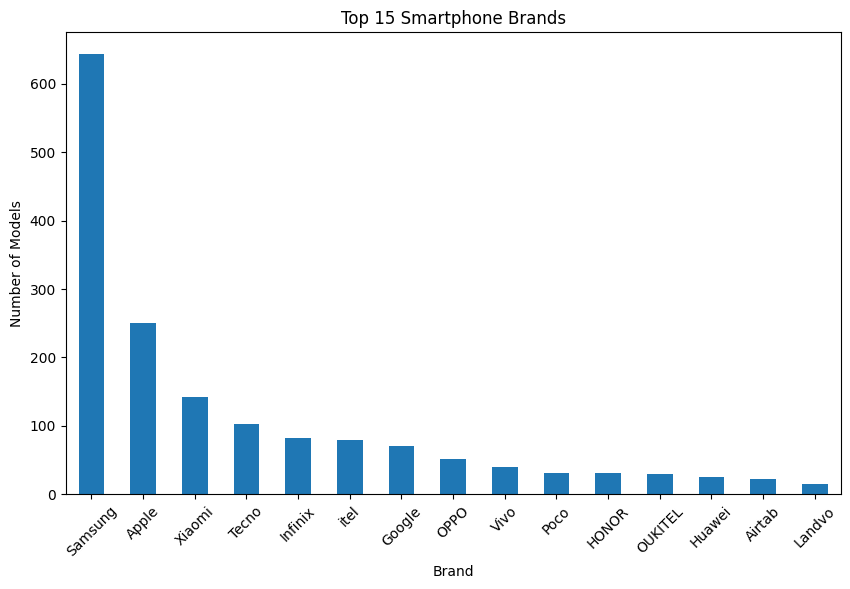

In [77]:
import matplotlib.pyplot as plt

brand_counts = product_unique["brand"].value_counts().head(15)

plt.figure(figsize=(10,6))
brand_counts.plot(kind="bar")
plt.title("Top 15 Smartphone Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Models")
plt.xticks(rotation=45)
plt.show()

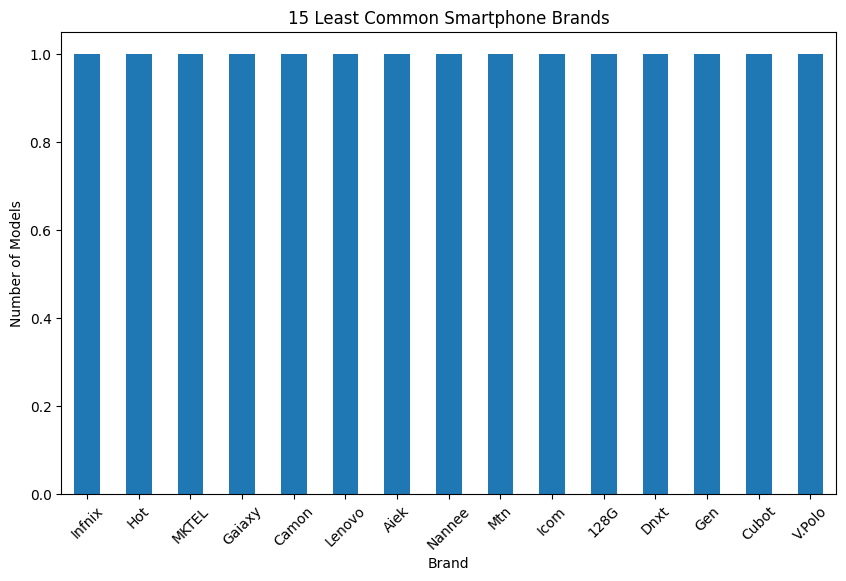

In [78]:
brand_counts = (
    product_unique["brand"]
    .value_counts()
    .sort_values(ascending=True)
    .head(15)
)

plt.figure(figsize=(10, 6))
brand_counts.plot(kind="bar")
plt.title("15 Least Common Smartphone Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Models")
plt.xticks(rotation=45)
plt.show()

In [79]:
brand_counts = (
    product_unique["brand"]
    .value_counts()
    .sort_values(ascending=True)
)

print(brand_counts.head(15))

brand
Infnix    1
Hot       1
MKTEL     1
Gaiaxy    1
Camon     1
Lenovo    1
Aiek      1
Nannee    1
Mtn       1
Icom      1
128G      1
Dnxt      1
Gen       1
Cubot     1
V.Polo    1
Name: count, dtype: int64


In [80]:
brand_counts = product_unique["brand"].value_counts()

product_unique["brand_grouped"] = product_unique["brand"].where(
    product_unique["brand"].isin(brand_counts[brand_counts >= 5].index),
    "Other"
)

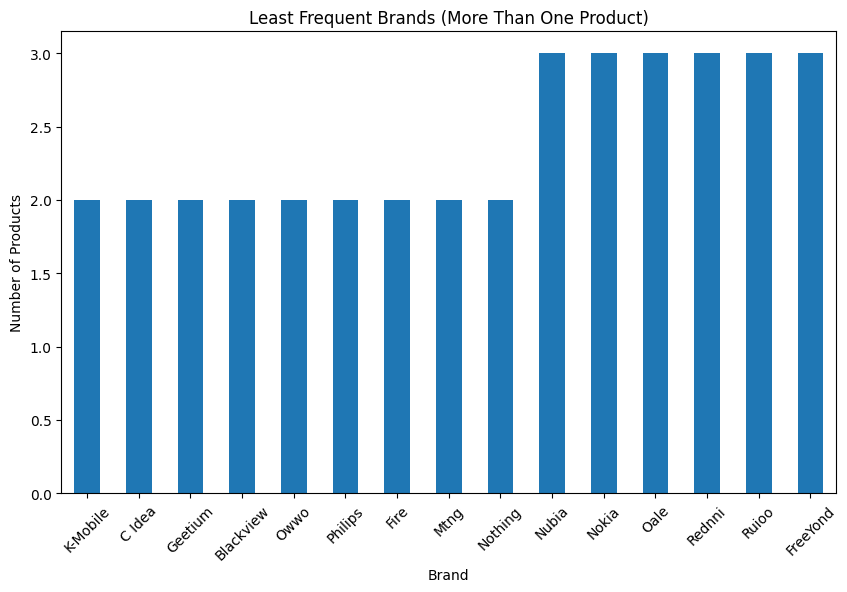

In [81]:
import matplotlib.pyplot as plt

least_brands = (
    product_unique["brand"]
    .value_counts()
    .loc[lambda x: x > 1]
    .sort_values()
    .head(15)
)

plt.figure(figsize=(10,6))
least_brands.plot(kind="bar")
plt.title("Least Frequent Brands (More Than One Product)")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

In [82]:
product_unique["price"].describe()

count    1.751000e+03
mean     5.741567e+05
std      6.360386e+05
min      4.180000e+04
25%      1.959995e+05
50%      3.400000e+05
75%      6.657000e+05
max      7.777777e+06
Name: price, dtype: float64

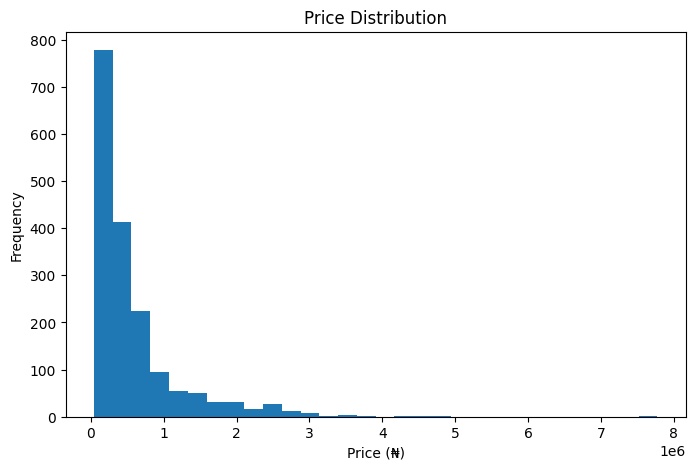

In [83]:
plt.figure(figsize=(8,5))

plt.hist(product_unique["price"], bins=30)

plt.title("Price Distribution")
plt.xlabel("Price (₦)")
plt.ylabel("Frequency")

plt.show()

In [84]:
brand_price = (
    product_unique
    .groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
)

brand_price.head(20)

brand
Apple       1.228093e+06
Nubia       9.903330e+05
Google      9.810352e+05
OnePlus     9.558750e+05
Motorola    9.125556e+05
ZTE         8.112854e+05
Nothing     7.750000e+05
Huawei      6.971232e+05
Samsung     5.797704e+05
Lenovo      5.655000e+05
Poco        3.844538e+05
HONOR       3.773652e+05
OPPO        3.687179e+05
K-Mobile    3.660000e+05
Xiaomi      3.528740e+05
Vivo        3.513892e+05
Infinix     3.484602e+05
Tecno       3.117814e+05
Realme      2.801495e+05
Nokia       2.499990e+05
Name: price, dtype: float64

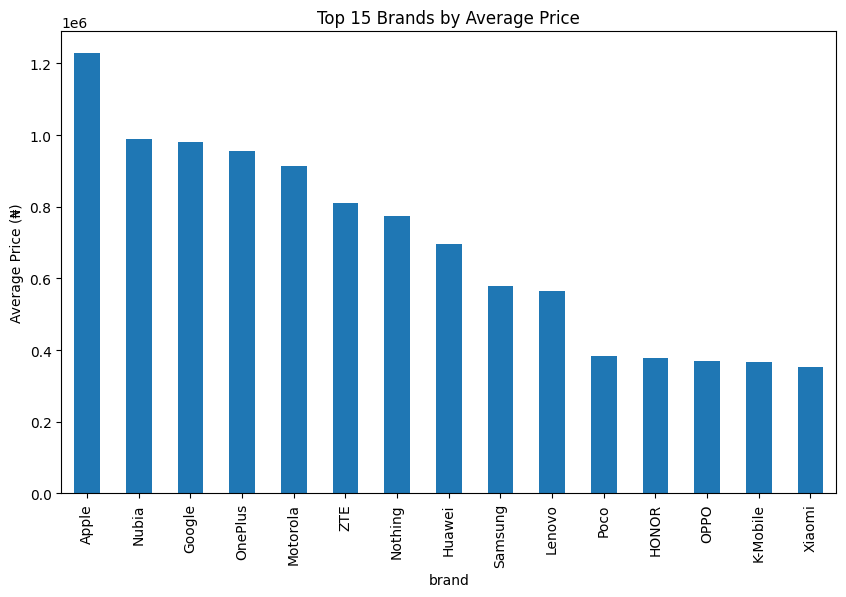

In [85]:
plt.figure(figsize=(10,6))

brand_price.head(15).plot(kind="bar")

plt.title("Top 15 Brands by Average Price")

plt.ylabel("Average Price (₦)")

plt.show()

In [86]:
product_unique["ram"].value_counts().sort_index()

ram
2.0      18
3.0      40
4.0     334
5.0       7
6.0     205
8.0     514
10.0      1
12.0    343
16.0     79
24.0     25
Name: count, dtype: int64

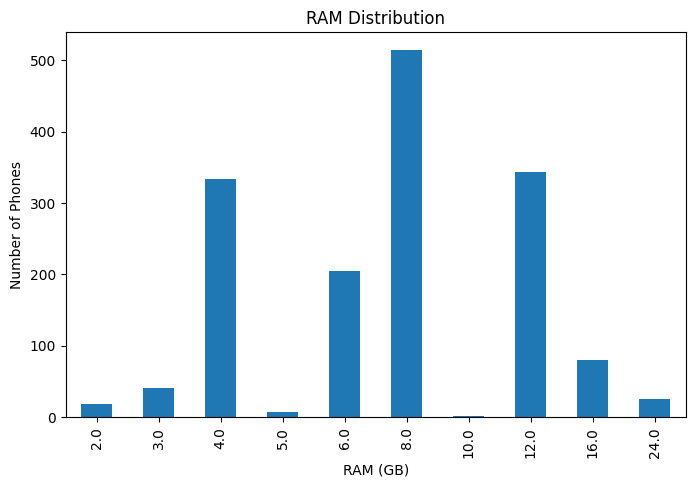

In [87]:
ram_counts = product_unique["ram"].value_counts().sort_index()

plt.figure(figsize=(8,5))

ram_counts.plot(kind="bar")

plt.title("RAM Distribution")

plt.xlabel("RAM (GB)")

plt.ylabel("Number of Phones")

plt.show()

In [88]:
product_unique["storage"].value_counts().sort_index()

storage
32.0       11
64.0      154
128.0     643
256.0     582
512.0     181
526.0       5
1024.0     45
2048.0      4
Name: count, dtype: int64

In [89]:
product_unique["os"].value_counts()

os
Android         907
iOS             194
Android 15      180
Android 16      147
Android 14       46
Android 13       17
iOS 26           16
iOS 18           10
Android 12        9
IOS 15            8
iOS 16            8
Android 10        7
iOS 17            6
HarmonyOS         6
IOS 14            5
Android15         3
Android 8.1       3
Android 128       3
HyperOS           2
Android10         2
Android 4000      2
iOS 4             2
iOS 13            2
Android 24        1
Android9          1
Android 9.0       1
Android15.0       1
Android 4         1
Android 11        1
Name: count, dtype: int64

In [90]:
product_unique["screen_size"].describe()

count    1478.000000
mean        6.703640
std         2.490643
min         2.000000
25%         6.400000
50%         6.700000
75%         6.800000
max        99.900000
Name: screen_size, dtype: float64

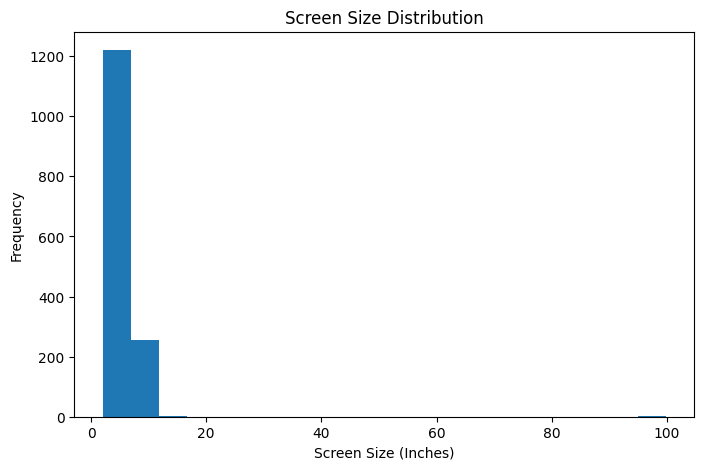

In [91]:
plt.figure(figsize=(8,5))

plt.hist(product_unique["screen_size"].dropna(), bins=20)

plt.title("Screen Size Distribution")

plt.xlabel("Screen Size (Inches)")

plt.ylabel("Frequency")

plt.show()

In [179]:
product_unique["discount"].describe()

count     1751
unique      77
top          0
freq       593
Name: discount, dtype: object

In [95]:
product_unique["rating"].mean()

np.float64(1.7042261564820103)

In [96]:
product_unique["rating"].value_counts().sort_index()

rating
0.0    1020
1.0      28
1.3       1
1.5       2
2.0      16
2.3       3
2.5       8
2.7       1
2.8       2
3.0      44
3.1       1
3.2      11
3.3      16
3.4       7
3.5      24
3.6      25
3.7      19
3.8      14
3.9       8
4.0      87
4.1      30
4.2      21
4.3      31
4.4      21
4.5      39
4.6      10
4.7      13
4.8      14
4.9       7
5.0     228
Name: count, dtype: int64

In [97]:
product_unique.nlargest(
    10,
    "reviews"
)[["name","brand","reviews","rating"]]

,name,brand,reviews,rating
0,XIAOMI Redmi 15C 6.9'' 8GBRAM/256GB ROM Androi...,Xiaomi,992,4.1
1,XIAOMI Redmi 15C 6.9'' 4GBRAM/128GB ROM Androi...,Xiaomi,750,4.1
2,"Samsung Galaxy A06 6.7"" 4GB RAM/ 128GB ROM And...",Samsung,682,4.2
3,"Samsung Galaxy A06 6.7"" 4GB RAM/64GB ROM Andro...",Samsung,615,4.1
4,XIAOMI Redmi 15C 6.9'' 4GB RAM/128GB ROM Andro...,Xiaomi,611,4.1
5,XIAOMI Redmi 15C 6.9'' 6GBRAM/128GB ROM Androi...,Xiaomi,515,4.3
6,"Samsung Galaxy A07 6.7"" 4GB RAM/128GB ROM - Black",Samsung,383,4.3
7,"redbeat D5 Android 14 Smartphones 4+64GB ROM, ...",Redbeat,329,3.6
8,"Samsung Galaxy A06 6.7"" 4GB RAM/128GB ROM Andr...",Samsung,319,4.0
9,"Poco C71 6.88"" 3GB RAM / 64GB ROM Android 15 -...",Poco,300,4.0


In [98]:
numeric = product_unique.select_dtypes(include="number")

numeric.corr()

,price,rating,reviews,ram,storage,screen_size
price,1.000000,-0.207582,-0.094876,0.449368,0.596107,0.013803
rating,-0.207582,1.000000,0.178989,-0.068682,-0.121473,0.029908
reviews,-0.094876,0.178989,1.000000,-0.088054,-0.066681,0.001944
ram,0.449368,-0.068682,-0.088054,1.000000,0.598289,0.061311
storage,0.596107,-0.121473,-0.066681,0.598289,1.000000,0.033674
screen_size,0.013803,0.029908,0.001944,0.061311,0.033674,1.000000


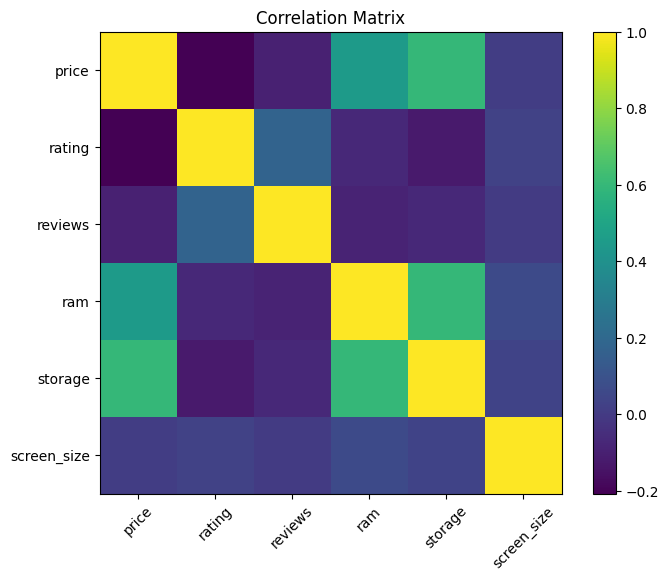

In [99]:
plt.figure(figsize=(8,6))

plt.imshow(numeric.corr())

plt.colorbar()

plt.xticks(
    range(len(numeric.columns)),
    numeric.columns,
    rotation=45
)

plt.yticks(
    range(len(numeric.columns)),
    numeric.columns
)

plt.title("Correlation Matrix")

plt.show()

In [100]:
product_unique.nlargest(
    10,
    "price"
)[["brand","name","price"]]

,brand,name,price
1750,Samsung,"Samsung Galaxy Z Trifold - 10"" (16GB RAM, 512G...",7777777.0
1749,Huawei,Huawei Mate XT Ultimate Design 10.2'' Tri-Fold...,4700000.0
1748,Samsung,"Samsung Galaxy Z Fold 7 5G 8.0"" -16GB RAM+ 1TB...",4464730.0
1747,Apple,Apple iPhone 17 Pro Max (2TB) – Silver (AFA),4398803.0
1746,Apple,Apple iPhone 17 Pro Max (1TB) – Silver (AFA),3822734.0
1745,Samsung,"Samsung Galaxy Z Fold 8 Ultra 5G - 8"" - 1TB RO...",3600000.0
1744,Samsung,Samsung Galaxy Fold 8 Ultra Dual SIM- 16GB RAM...,3599000.0
1743,ZTE,"ZTE RedMagic 10 Pro - 6.85"" (24GB RAM, 1TB ROM...",3500000.0
1742,Samsung,Samsung Galaxy Z Fold 8 Ultra 5G - 16GB RAM + ...,3450000.0
1741,Apple,Apple iPhone 17 Pro (1TB) – Deep Blue (AFA),3293690.0


In [101]:
product_unique.nsmallest(
    10,
    "price"
)[["brand","name","price"]]

,brand,name,price
319,itel,"itel it9320 4G Android Feature Phone, 2.8 Inch...",41800.0
731,itel,itel 9320 Dual Sim 2GB RAM/16GB ROM Android 4G...,41800.0
148,MKTEL,"MKTEL A19 Pro Mini 4.5"" Android 10 Phone 2+16G...",54554.0
53,Huawei,"Renewed Huawei Y5P Black 5.45"" 4+64G 8MP 3020m...",55225.0
732,Apple,"iphone 6 99.9 %NEW 4.7"" Ram 1G Rom 16G 1.2Mp +...",60000.0
107,Vivo,"Vivo Y85 4Gb RAM+64Gb ROM 6.22"" Large Screen D...",60716.0
733,OPPO,"OPPOA57 smartphone, Android system, 5.2-inch d...",61560.0
37,OPPO,Oppo A3S 4GB RAM+64GB ROM -4G LTE Dual SIM 6.2...,62557.0
124,OPPO,"OPPO A3s Blue 4+64GB 6.2"" HD FullScreen Displa...",64604.0
320,OPPO,"OPPO A3s Pink 4+64GB 6.2"" HD FullScreen Displa...",64604.0


In [102]:
brand_market = (
    product_unique["brand"]
    .value_counts()
    .reset_index()
)

brand_market.columns = ["Brand", "Number_of_Products"]

brand_market.head(10)

,Brand,Number_of_Products
0,Samsung,643
1,Apple,251
2,Xiaomi,142
3,Tecno,103
4,Infinix,82
5,itel,80
6,Google,71
7,OPPO,51
8,Vivo,40
9,Poco,31


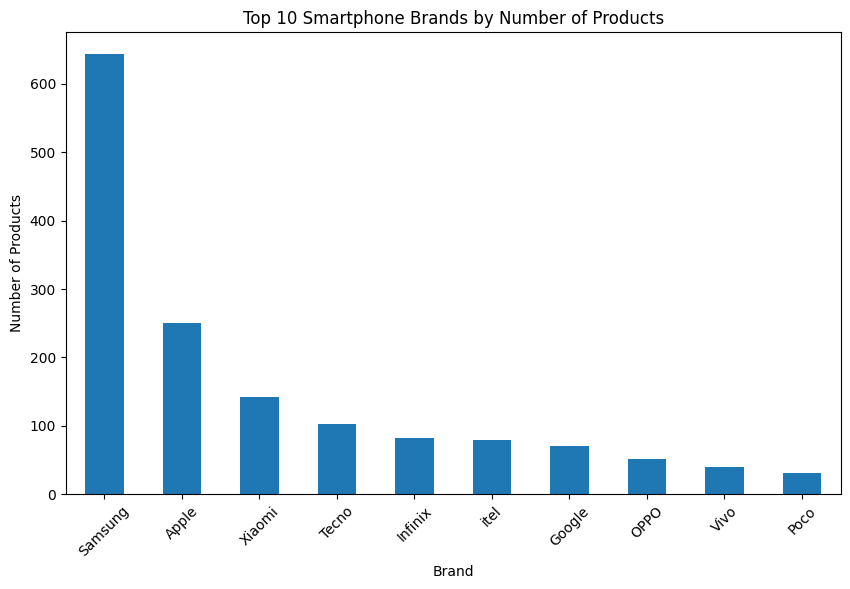

In [103]:
import matplotlib.pyplot as plt

top10 = product_unique["brand"].value_counts().head(10)

plt.figure(figsize=(10, 6))

top10.plot(kind="bar")

plt.title("Top 10 Smartphone Brands by Number of Products")
plt.xlabel("Brand")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

In [104]:
market_share = (
    product_unique["brand"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

market_share.columns = ["Brand", "Market Share (%)"]

market_share.head(10)

,Brand,Market Share (%)
0,Samsung,36.72
1,Apple,14.33
2,Xiaomi,8.11
3,Tecno,5.88
4,Infinix,4.68
5,itel,4.57
6,Google,4.05
7,OPPO,2.91
8,Vivo,2.28
9,Poco,1.77


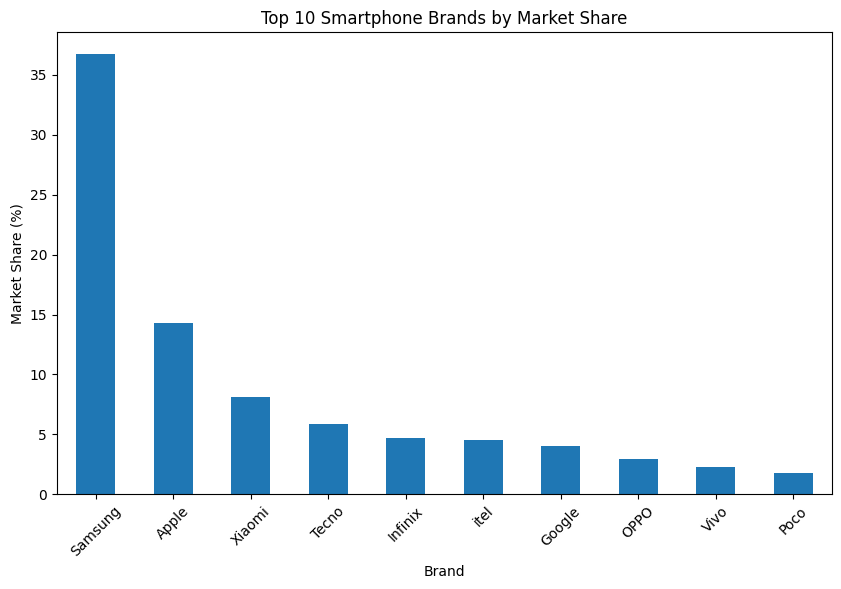

In [105]:
top10_share = (
    product_unique["brand"]
    .value_counts(normalize=True)
    .head(10)
    * 100
)

plt.figure(figsize=(10, 6))

top10_share.plot(kind="bar")

plt.title("Top 10 Smartphone Brands by Market Share")
plt.xlabel("Brand")
plt.ylabel("Market Share (%)")

plt.xticks(rotation=45)

plt.show()

## Calculate the average price for each brand

In [106]:
brand_price = (
    product_unique
    .groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

brand_price.columns = ["Brand", "Average Price (₦)"]

brand_price.head(15)

,Brand,Average Price (₦)
0,Apple,1228092.65
1,Nubia,990333.00
2,Google,981035.21
3,OnePlus,955875.00
4,Motorola,912555.56
5,ZTE,811285.43
6,Nothing,775000.00
7,Huawei,697123.24
8,Samsung,579770.35
9,Lenovo,565500.00


## Display the Top 15 most expensive brands

In [107]:
brand_price.head(15)

,Brand,Average Price (₦)
0,Apple,1228092.65
1,Nubia,990333.00
2,Google,981035.21
3,OnePlus,955875.00
4,Motorola,912555.56
5,ZTE,811285.43
6,Nothing,775000.00
7,Huawei,697123.24
8,Samsung,579770.35
9,Lenovo,565500.00


## Visualize the Top 15 brands by average price

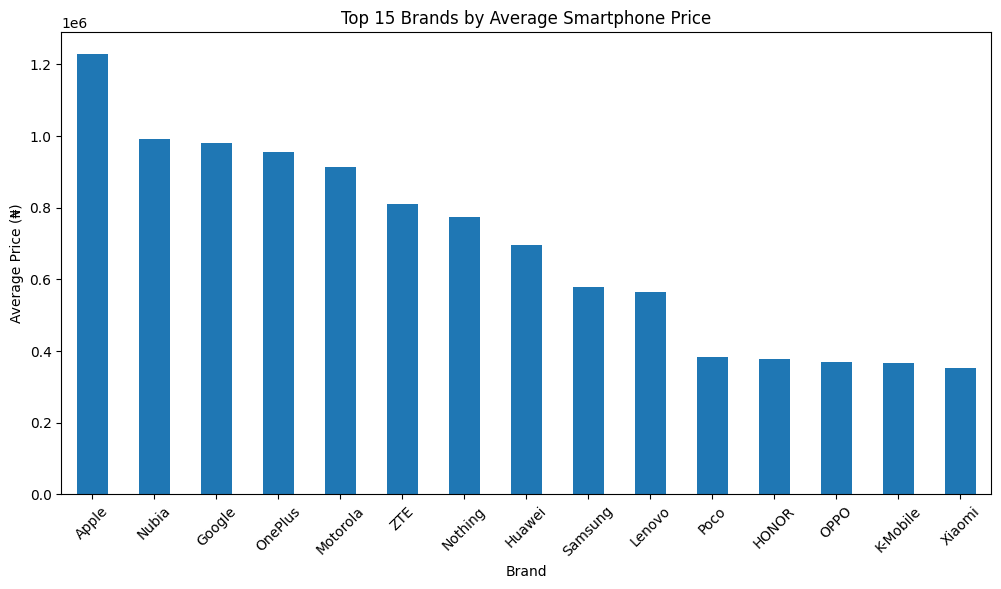

In [108]:
import matplotlib.pyplot as plt

top15 = (
    product_unique
    .groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

top15.plot(kind="bar")

plt.title("Top 15 Brands by Average Smartphone Price")
plt.xlabel("Brand")
plt.ylabel("Average Price (₦)")

plt.xticks(rotation=45)

plt.show()

## The 10 least expensive brands

In [109]:
lowest10 = (
    product_unique
    .groupby("brand")["price"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

lowest10

brand
MKTEL      54554.0
Geetium    76500.0
C Idea     79890.0
Mtn        85000.0
V.Polo     86808.0
Rednni     92343.0
Aiek       92500.0
Icom       99000.0
128G       99029.0
Dnxt       99500.0
Name: price, dtype: float64

## Visualize 10 least expensive brands

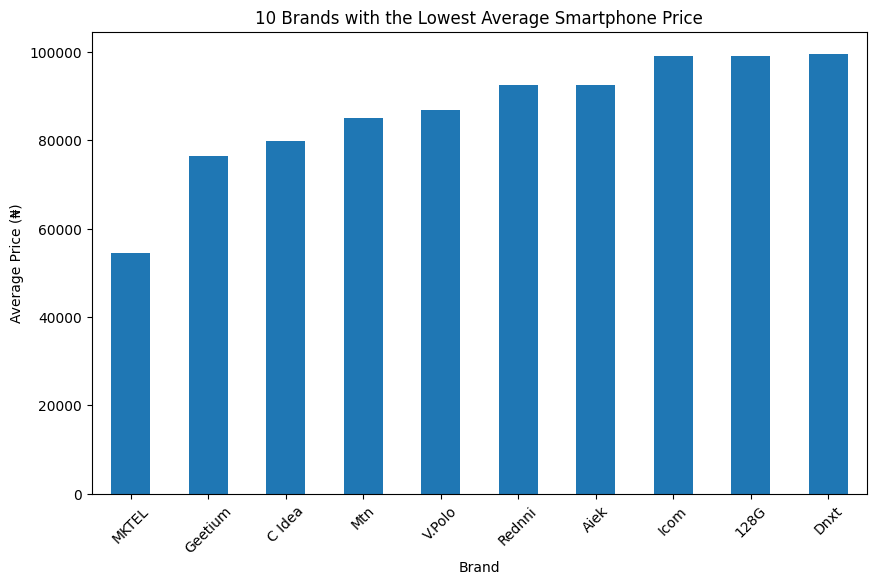

In [150]:
plt.figure(figsize=(10, 6))

lowest10.plot(kind="bar")

plt.title("10 Brands with the Lowest Average Smartphone Price")
plt.xlabel("Brand")
plt.ylabel("Average Price (₦)")

plt.xticks(rotation=45)

plt.show()

## After running the analysis to known Which brands sell the most expensive smartphones on average?

#### Brands such as Apple, Samsung, and Google have the highest average smartphone prices, 
#### indicating a focus on premium and flagship devices. In contrast, brands like Mktel, Geetium, 
#### and FreeYond offer lower average prices, reflecting their emphasis on budget-friendly smartphones. 
#### These pricing differences highlight how manufacturers position themselves to target different 
#### customer segments in the market.

In [151]:
model_price = (
    product_unique
    .dropna(subset=["model"])
    .groupby("model")["price"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

model_price.columns = ["Model", "Average Price (₦)"]

model_price.head(15)

,Model,Average Price (₦)
0,Mate Xt,4700000.00
1,Galaxy Z Fold 8,3081083.33
2,iPhone 17 Pro Max,2602317.52
3,Find X9 Ultra,2550000.00
4,X300,2499000.00
5,Galaxy Z Fold 7,2322222.90
6,iPhone 17 Pro,2316806.36
7,Find X9 Pro,2222000.00
8,X7,2100000.00
9,iPhone 16 Pro Max,2001666.67


## Which brands offer the highest discounts?

## Which smartphone brands provide the biggest discounts on their products?

#### Brands at the top of the chart are the ones that, on average, offer the highest promotional discounts, making them more attractive to price-sensitive customers. The Discounted_Products column also shows how many discounted products each brand has, helping you judge whether the average is based on many products or just a few.

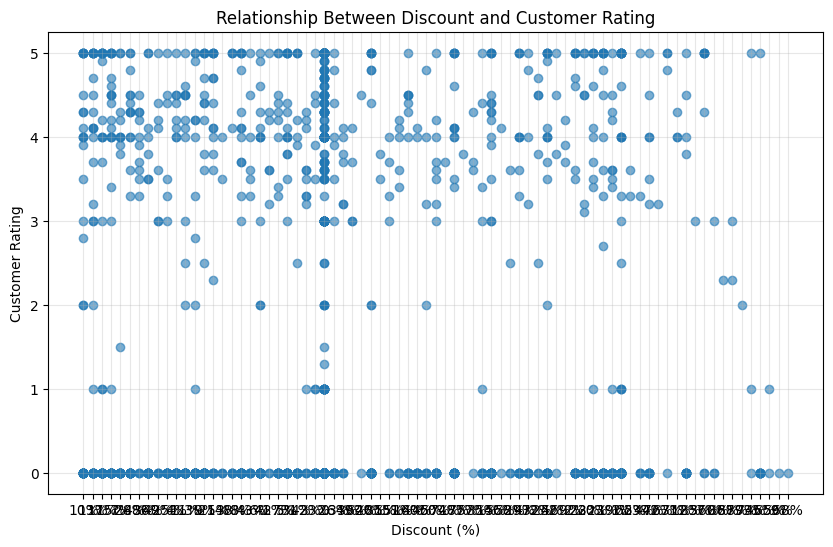

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    product_unique["discount"],
    product_unique["rating"],
    alpha=0.6
)

plt.title("Relationship Between Discount and Customer Rating")
plt.xlabel("Discount (%)")
plt.ylabel("Customer Rating")

plt.grid(alpha=0.3)

plt.show()

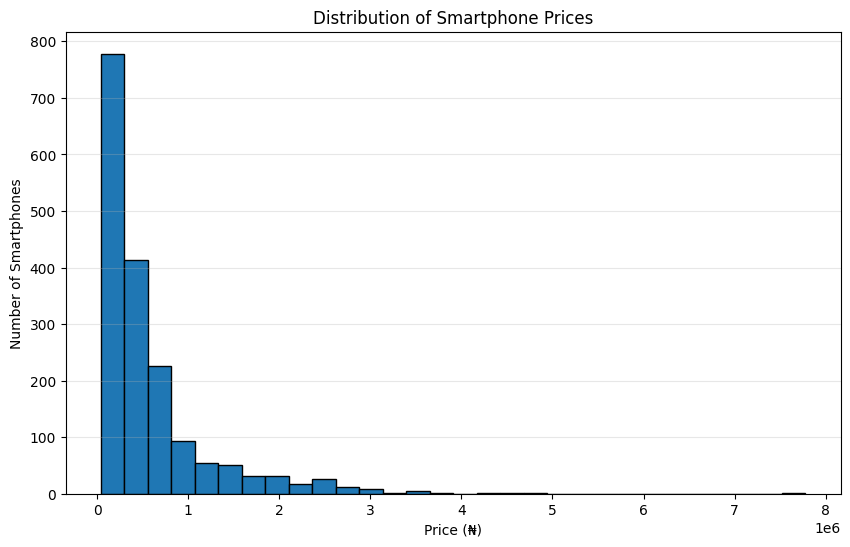

In [153]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    product_unique["price"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (₦)")
plt.ylabel("Number of Smartphones")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [154]:
price_distribution = product_unique["price"].describe().round(2)

print(price_distribution)

count       1751.00
mean      574156.70
std       636038.56
min        41800.00
25%       195999.50
50%       340000.00
75%       665700.00
max      7777777.00
Name: price, dtype: float64


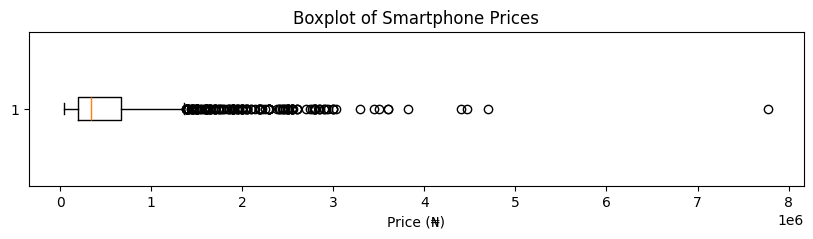

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))

plt.boxplot(product_unique["price"], vert=False)

plt.title("Boxplot of Smartphone Prices")
plt.xlabel("Price (₦)")

plt.show()

## Counting of Price Range

In [156]:
import pandas as pd

# Define price ranges
price_bins = [
    0,
    100000,
    200000,
    300000,
    500000,
    700000,
    1000000,
    float("inf")
]

price_labels = [
    "₦0 - ₦100k",
    "₦100k - ₦200k",
    "₦200k - ₦300k",
    "₦300k - ₦500k",
    "₦500k - ₦700k",
    "₦700k - ₦1M",
    "Above ₦1M"
]

# Create price range column
product_unique["Price Range"] = pd.cut(
    product_unique["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

# Count products in each price range
price_range_count = (
    product_unique["Price Range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

price_range_count.columns = ["Price Range", "Number of Products"]

price_range_count

,Price Range,Number of Products
0,₦0 - ₦100k,94
1,₦100k - ₦200k,370
2,₦200k - ₦300k,334
3,₦300k - ₦500k,328
4,₦500k - ₦700k,231
5,₦700k - ₦1M,144
6,Above ₦1M,250


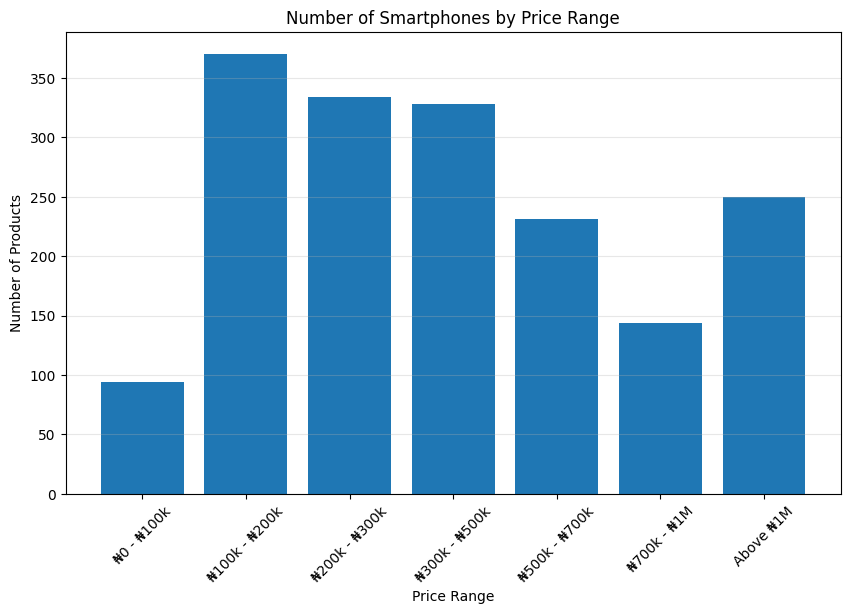

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    price_range_count["Price Range"],
    price_range_count["Number of Products"]
)

plt.title("Number of Smartphones by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insight

#### The analysis groups smartphones into different price segments and identifies which range contains the highest number of products. This reveals the market segment where most smartphones are concentrated, helping retailers understand customer demand, optimize inventory, and develop pricing strategies.

In [158]:
most_common_range = price_range_count.loc[
    price_range_count["Number of Products"].idxmax()
]

print(most_common_range)

Price Range           ₦100k - ₦200k
Number of Products              370
Name: 1, dtype: object


In [159]:
brand_value = (
    product_unique
    .groupby("brand")
    .agg(
        Average_Price=("price", "mean"),
        Average_Rating=("rating", "mean"),
        Number_of_Products=("brand", "count")
    )
    .reset_index()
)

# Consider only brands with at least 5 products
brand_value = brand_value[
    brand_value["Number_of_Products"] >= 5
]

# Value Score = Rating per ₦100,000
brand_value["Value_Score"] = (
    brand_value["Average_Rating"] /
    (brand_value["Average_Price"] / 100000)
).round(2)

brand_value = brand_value.sort_values(
    "Value_Score",
    ascending=False
)

brand_value.head(15)

,brand,Average_Price,Average_Rating,Number_of_Products,Value_Score
1,Agm,158621.200000,4.320000,5,2.72
40,OUKITEL,174851.431034,3.451724,29,1.97
10,DOOGEE,161095.200000,3.130000,10,1.94
12,FOSSiBOT,185486.500000,2.700000,8,1.46
57,itel,187904.325000,1.900000,80,1.01
30,Lesia,123599.600000,0.920000,5,0.74
28,Landvo,155288.666667,1.026667,15,0.66
39,OPPO,368717.882353,1.905882,51,0.52
20,HONOR,377365.225806,1.758065,31,0.47
55,Xiaomi,352874.028169,1.612676,142,0.46


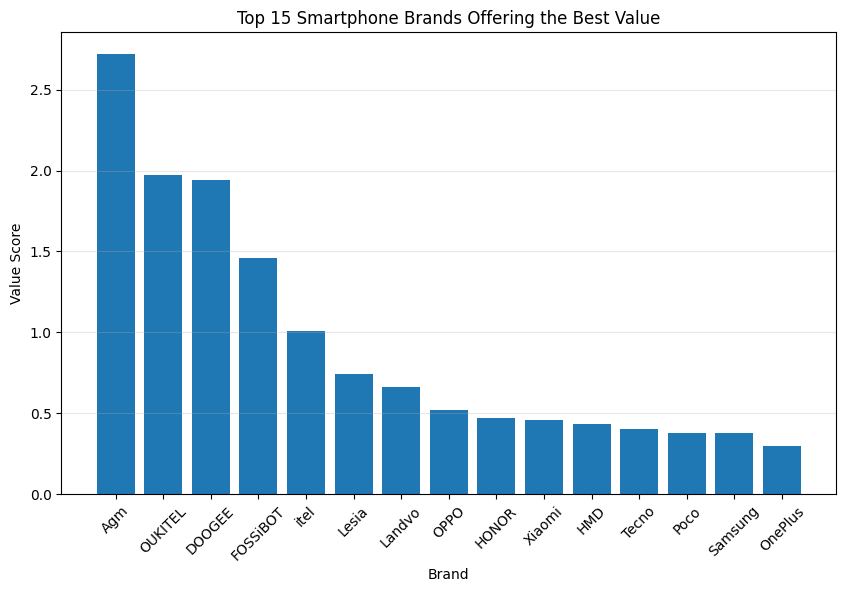

In [160]:
import matplotlib.pyplot as plt

top_value = brand_value.head(15)

plt.figure(figsize=(10,6))

plt.bar(
    top_value["brand"],
    top_value["Value_Score"]
)

plt.title("Top 15 Smartphone Brands Offering the Best Value")
plt.xlabel("Brand")
plt.ylabel("Value Score")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [161]:
brand_rating = (
    product_unique
    .groupby("brand")
    .agg(
        Average_Rating=("rating", "mean"),
        Number_of_Products=("brand", "count")
    )
    .reset_index()
)

# Keep brands with at least 5 products
brand_rating = brand_rating[
    brand_rating["Number_of_Products"] >= 5
]

brand_rating = brand_rating.sort_values(
    by="Average_Rating",
    ascending=False
).round(2)

brand_rating.head(15)

,brand,Average_Rating,Number_of_Products
1,Agm,4.32,5
40,OUKITEL,3.45,29
10,DOOGEE,3.13,10
42,OnePlus,2.84,8
12,FOSSiBOT,2.70,8
50,Samsung,2.17,643
39,OPPO,1.91,51
57,itel,1.90,80
23,Huawei,1.86,25
20,HONOR,1.76,31


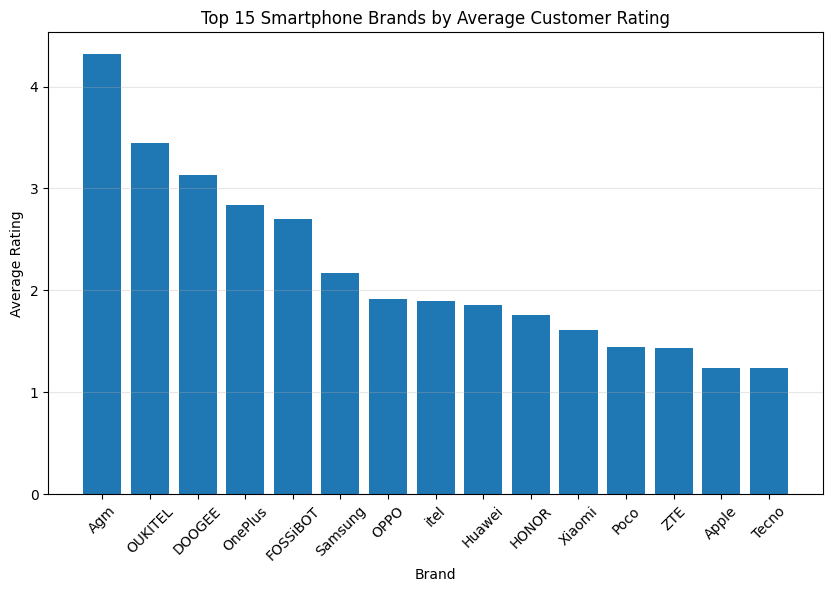

In [162]:
import matplotlib.pyplot as plt

top_rating = brand_rating.head(15)

plt.figure(figsize=(10,6))

plt.bar(
    top_rating["brand"],
    top_rating["Average_Rating"]
)

plt.title("Top 15 Smartphone Brands by Average Customer Rating")
plt.xlabel("Brand")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Top Smartphone Models by Customer Reviews

In [163]:
model_reviews = (
    product_unique
    .dropna(subset=["model"])
    .groupby(["brand", "model"], as_index=False)["reviews"]
    .sum()
    .sort_values(by="reviews", ascending=False)
)

model_reviews.head(15)

,brand,model,reviews
293,Xiaomi,Redmi 15C,3108
182,Samsung,Galaxy A06,2114
183,Samsung,Galaxy A07,777
177,Redbeat,D5,456
160,Poco,Poco C71,398
113,OPPO,A31,382
188,Samsung,Galaxy A17,304
292,Xiaomi,Redmi 15,279
163,Poco,Poco C85,277
179,Ruioo,Galaxy S25 Ultra,257


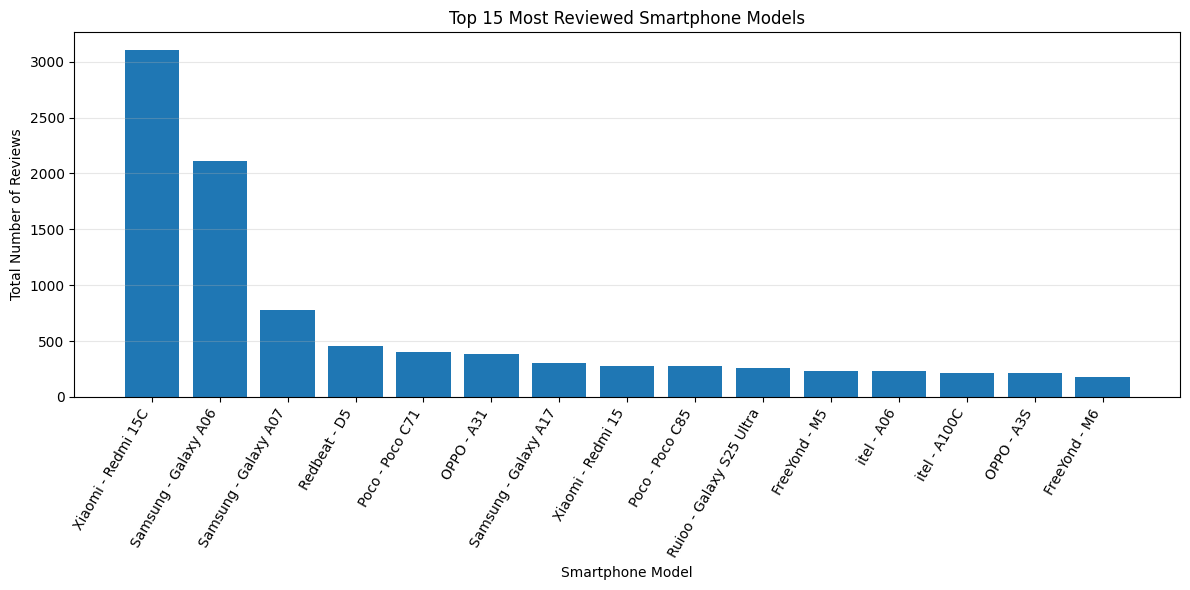

In [164]:
import matplotlib.pyplot as plt

# Top 15 most reviewed models
top_models = model_reviews.head(15).copy()

# Create labels like "Samsung - Galaxy A06"
top_models["Brand_Model"] = (
    top_models["brand"] + " - " + top_models["model"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_models["Brand_Model"],
    top_models["reviews"]
)

plt.title("Top 15 Most Reviewed Smartphone Models")
plt.xlabel("Smartphone Model")
plt.ylabel("Total Number of Reviews")

plt.xticks(rotation=60, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

##### The chart highlights the smartphone models with the highest total customer reviews. Models such as the Samsung Galaxy A06 and Xiaomi Redmi 15C receive significantly more reviews than other smartphones, suggesting they are among the most popular or highest-selling devices in the market. High review counts may indicate strong customer demand and greater market visibility.

In [165]:
ram_distribution = (
    product_unique
    .dropna(subset=["ram"])
    .groupby("ram")
    .size()
    .reset_index(name="Number of Smartphones")
    .sort_values(by="ram")
)

ram_distribution.columns = ["RAM (GB)", "Number of Smartphones"]

ram_distribution

,RAM (GB),Number of Smartphones
0,2.0,18
1,3.0,45
2,4.0,356
3,5.0,7
4,6.0,217
5,8.0,533
6,10.0,1
7,12.0,353
8,16.0,79
9,24.0,25


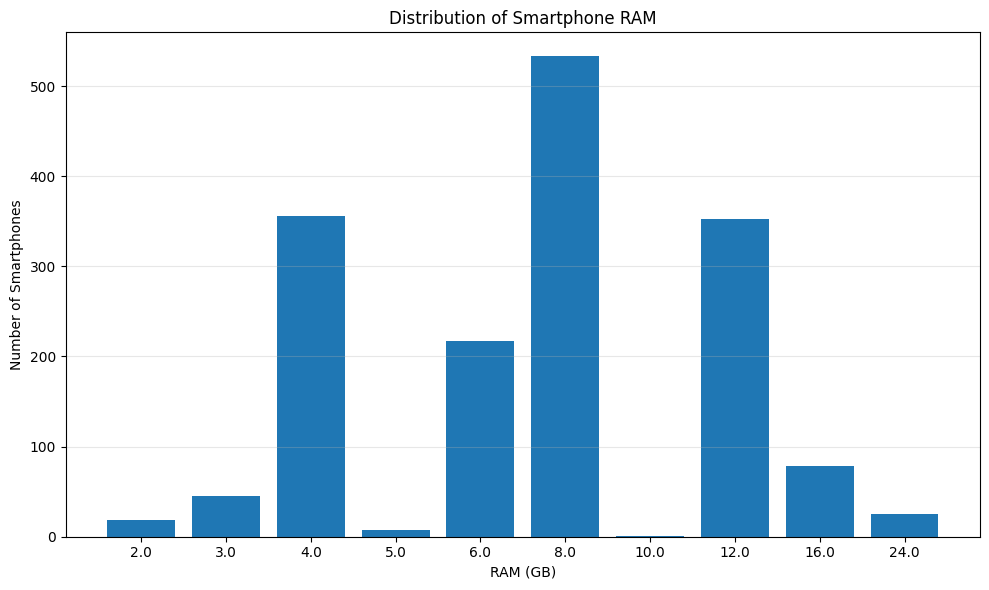

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    ram_distribution["RAM (GB)"].astype(str),
    ram_distribution["Number of Smartphones"]
)

plt.title("Distribution of Smartphone RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Smartphones")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [167]:
storage_distribution = (
    product_unique
    .dropna(subset=["storage"])
    .groupby("storage")
    .size()
    .reset_index(name="Number of Smartphones")
    .sort_values(by="storage")
)

storage_distribution.columns = ["Storage (GB)", "Number of Smartphones"]

storage_distribution

,Storage (GB),Number of Smartphones
0,32.0,11
1,64.0,154
2,128.0,643
3,256.0,582
4,512.0,181
5,526.0,5
6,1024.0,45
7,2048.0,4


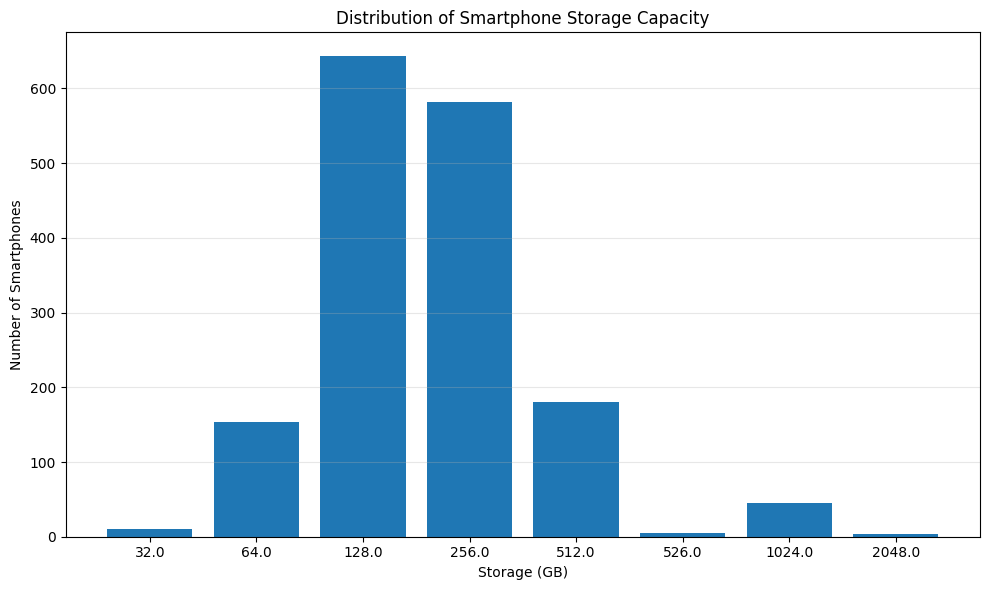

In [168]:
plt.figure(figsize=(10,6))

plt.bar(
    storage_distribution["Storage (GB)"].astype(str),
    storage_distribution["Number of Smartphones"]
)

plt.title("Distribution of Smartphone Storage Capacity")
plt.xlabel("Storage (GB)")
plt.ylabel("Number of Smartphones")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [169]:
phones_3_to_12_storage = (
    product_unique[
        product_unique["storage"].between(3, 12, inclusive="both")
    ][["brand", "model", "name", "storage"]]
    .sort_values(by="storage")
    .reset_index(drop=True)
)

phones_3_to_12_storage

,brand,model,name,storage


In [170]:
product_unique.loc[
    product_unique["name"].str.contains(
        "3GB|12GB",
        case=False,
        na=False
    ),
    ["brand", "name", "ram", "storage"]
].head(20)

,brand,name,ram,storage
9,Poco,"Poco C71 6.88"" 3GB RAM / 64GB ROM Android 15 -...",3.0,64.0
29,Poco,"Poco C71 6.88"" 3GB RAM / 64GB ROM Android 15 -...",3.0,64.0
58,Samsung,"Samsung Galaxy S22 Ultra 5G - 6.8"" 256GB/12GB,...",12.0,256.0
73,Samsung,"Samsung Galaxy S21 Ultra 5G - 6.8"" 256GB/12GB,...",12.0,256.0
77,Samsung,"Samsung Galaxy S21 Ultra 5G-6.8"" (128GB, 12GB ...",12.0,128.0
85,Samsung,Samsung Galaxy Note 10 Plus (Note 10+) 6.8-Inc...,12.0,256.0
105,Samsung,Samsung Galaxy S20 Ultra - 6.9'' - 12GB RAM 12...,12.0,128.0
109,Samsung,Samsung GALAXY S20 ULTRA 5G SINGLE SIM 108PM+4...,12.0,NaN
115,Samsung,Samsung Galaxy Note 10 Plus (Note 10+) 6.8'' (...,12.0,256.0
117,Samsung,"Samsung Galaxy Z Fold 4 1 SIM - 12GB RAM, 512G...",12.0,512.0


In [171]:
product_unique.isna().sum()

name               0
price              0
image              0
link               0
discount           0
rating             0
reviews            0
brand              0
ram              117
storage          126
os               160
color            436
model            219
screen_size      273
product_model      0
brand_grouped      0
Price Range        0
dtype: int64

In [172]:
product_info.isna().sum()

name             0
price            0
image            0
link             0
discount         0
rating           0
reviews          0
brand            0
ram            225
storage         16
os             180
color          496
model          269
screen_size    292
dtype: int64

In [173]:
product_unique.loc[
    product_unique["ram"].isna(),
    ["brand", "name", "ram", "storage"]
].head(30)

,brand,name,ram,storage
51,Agm,AGM AGM H MAX 4G Rugged Smartphone Android 14 ...,NaN,128.0
53,Huawei,"Renewed Huawei Y5P Black 5.45"" 4+64G 8MP 3020m...",NaN,NaN
59,itel,"itel SUPER 26Ultra 6.78"" 3D-Curved Amoled,144H...",NaN,128.0
72,itel,"itel SUPER 26Ultra 6.78"" 3D-Curved Amoled,144H...",NaN,128.0
74,OPPO,"OPPO A3s Purple 6.2"" 4+64G 13MP+2MP 3400mAh Wi...",NaN,NaN
80,Samsung,"Samsung Galaxy S21 Plus 6.7"" 128GB S21+ Smartp...",NaN,128.0
88,Samsung,Samsung Galaxy S22 S9010 5G Android 12 8+128G ...,NaN,NaN
98,OPPO,Oppo MAMBA CERTIFIED A3s 64G Long Battery 6.2'...,NaN,NaN
102,Vivo,"Vivo Y93s Black 6.2"" 6+128G 13MP+2MP 4030mAh W...",NaN,NaN
110,Geetium,GEETIUM 4G Portable Fast Browsing Mini Android...,NaN,NaN


In [174]:
missing_ram = product_unique["ram"].isna()

product_unique.loc[missing_ram, "ram"] = (
    product_unique.loc[missing_ram, "name"]
    .apply(extract_missing_ram)
)

In [175]:
product_unique.loc[
    product_unique["storage"].isna(),
    ["brand", "name", "ram", "storage"]
].head(30)

,brand,name,ram,storage
11,OPPO,Oppo A31 6GB RAM+128G ROM 4230mAh Dual SIM6.5 ...,6.0,NaN
28,OPPO,Oppo A31 6GB RAM+128G ROM Dual SIM6.5 Inch Scr...,6.0,NaN
43,itel,"itel City 200 7.45mm"" 128/4+4gb Unibody Metall...",4.0,NaN
53,Huawei,"Renewed Huawei Y5P Black 5.45"" 4+64G 8MP 3020m...",NaN,NaN
66,itel,"itel City 200 7.45mm"" 128/4+4gb Unibody Metall...",4.0,NaN
74,OPPO,"OPPO A3s Purple 6.2"" 4+64G 13MP+2MP 3400mAh Wi...",NaN,NaN
86,itel,"itel City 200 7.45mm"" 128/4+4gb Unibody Metall...",4.0,NaN
88,Samsung,Samsung Galaxy S22 S9010 5G Android 12 8+128G ...,NaN,NaN
98,OPPO,Oppo MAMBA CERTIFIED A3s 64G Long Battery 6.2'...,NaN,NaN
102,Vivo,"Vivo Y93s Black 6.2"" 6+128G 13MP+2MP 4030mAh W...",NaN,NaN


In [176]:
product_unique.loc[
    product_unique["ram"].isna(),
    ["brand", "name", "ram", "storage"]
]

,brand,name,ram,storage
51,Agm,AGM AGM H MAX 4G Rugged Smartphone Android 14 ...,NaN,128.0
53,Huawei,"Renewed Huawei Y5P Black 5.45"" 4+64G 8MP 3020m...",NaN,NaN
59,itel,"itel SUPER 26Ultra 6.78"" 3D-Curved Amoled,144H...",NaN,128.0
72,itel,"itel SUPER 26Ultra 6.78"" 3D-Curved Amoled,144H...",NaN,128.0
74,OPPO,"OPPO A3s Purple 6.2"" 4+64G 13MP+2MP 3400mAh Wi...",NaN,NaN
...,...,...,...,...
1724,Apple,Apple iPhone 17 Pro (512GB) – Deep Blue (AFA),NaN,512.0
1740,Apple,Apple iPhone 17 Pro Max – 512GB – Cosmic Orange,NaN,512.0
1741,Apple,Apple iPhone 17 Pro (1TB) – Deep Blue (AFA),NaN,1024.0
1746,Apple,Apple iPhone 17 Pro Max (1TB) – Silver (AFA),NaN,1024.0


In [177]:
product_unique.isna().sum()

name               0
price              0
image              0
link               0
discount           0
rating             0
reviews            0
brand              0
ram              117
storage          126
os               160
color            436
model            219
screen_size      273
product_model      0
brand_grouped      0
Price Range        0
dtype: int64